<a href="https://colab.research.google.com/github/diem2701/NH-M-7---T-I-7/blob/main/D%E1%BB%B1%20b%C3%A1o%20h%C3%A0nh%20vi%20g%E1%BB%ADi%20ti%E1%BB%81n%20v%C3%A0%20s%E1%BB%91%20d%C6%B0%20t%C3%A0i%20kho%E1%BA%A3n%20kh%C3%A1ch%20h%C3%A0ng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ỨNG DỤNG HỌC MÁY TRONG DỰ BÁO HÀNH VI GỬI TIỀN VÀ SỐ DƯ TÀI KHOẢN KHÁCH HÀNG NGÂN HÀNG

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

#Tiền xử lý dữ liệu

In [ ]:
df = pd.read_csv("bank.csv")
print("Kích thước dữ liệu:", df.shape)
print("\n5 dòng đầu tiên:")
df.head()

Kích thước dữ liệu: (11162, 17)

5 dòng đầu tiên:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [ ]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


Target distribution:
 deposit
no     5873
yes    5289
Name: count, dtype: int64


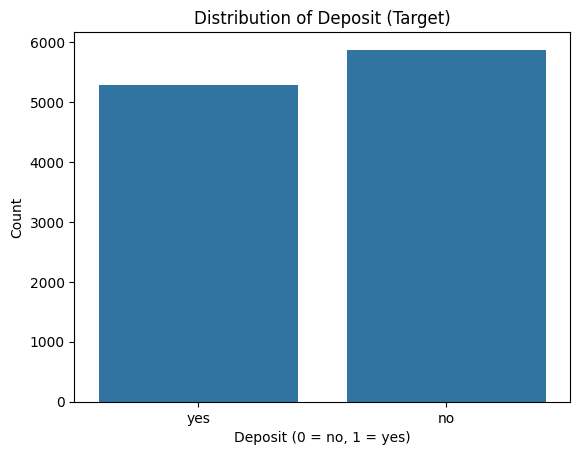

In [ ]:
# ── Kiểm tra phân bố target ──
import matplotlib.pyplot as plt
import seaborn as sns

# Phân bố deposit
target_counts = df['deposit'].value_counts()
print("Target distribution:\n", target_counts)

# Vẽ bar chart
sns.countplot(x='deposit', data=df)
plt.title("Distribution of Deposit (Target)")
plt.xlabel("Deposit (0 = no, 1 = yes)")
plt.ylabel("Count")
plt.show()

1. Nhận xét về phân bổ số lượng

Tổng quan: Biến mục tiêu deposit chia thành hai nhóm rõ rệt: no (không đăng ký) và yes (có đăng ký).

Số liệu cụ thể:

Nhóm no: 5.873 quan sát.

Nhóm yes: 5.289 quan sát.

Sự chênh lệch: Số lượng khách hàng không đăng ký tiền gửi (no) cao hơn so với khách hàng có đăng ký (yes) khoảng 584 quan sát.

2. Đánh giá tính cân bằng của dữ liệu (Balance Check)
Tỷ lệ: Nhóm "no" chiếm khoảng 52,6% và nhóm "yes" chiếm khoảng 47,4% tổng tập dữ liệu.

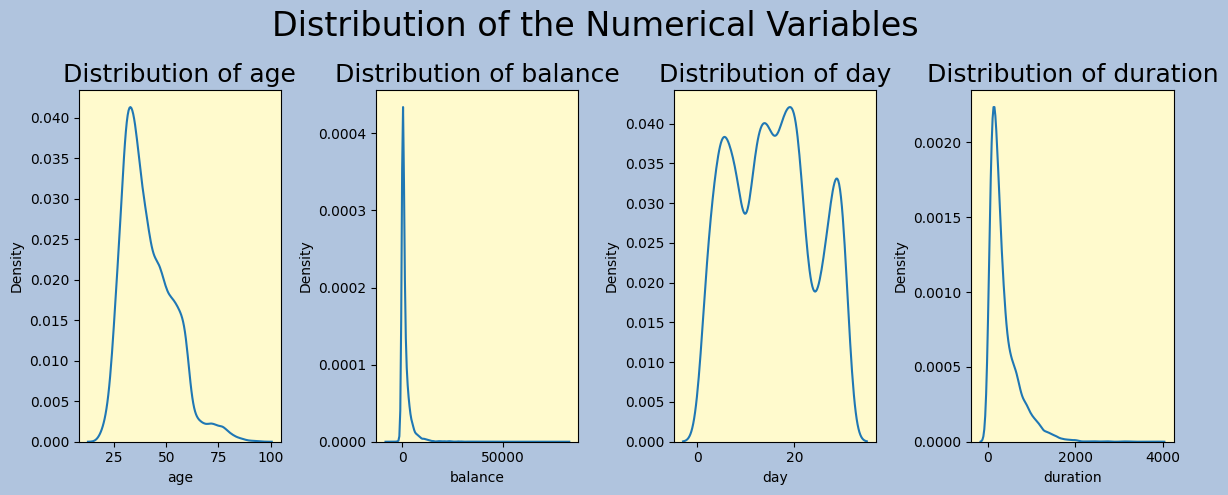

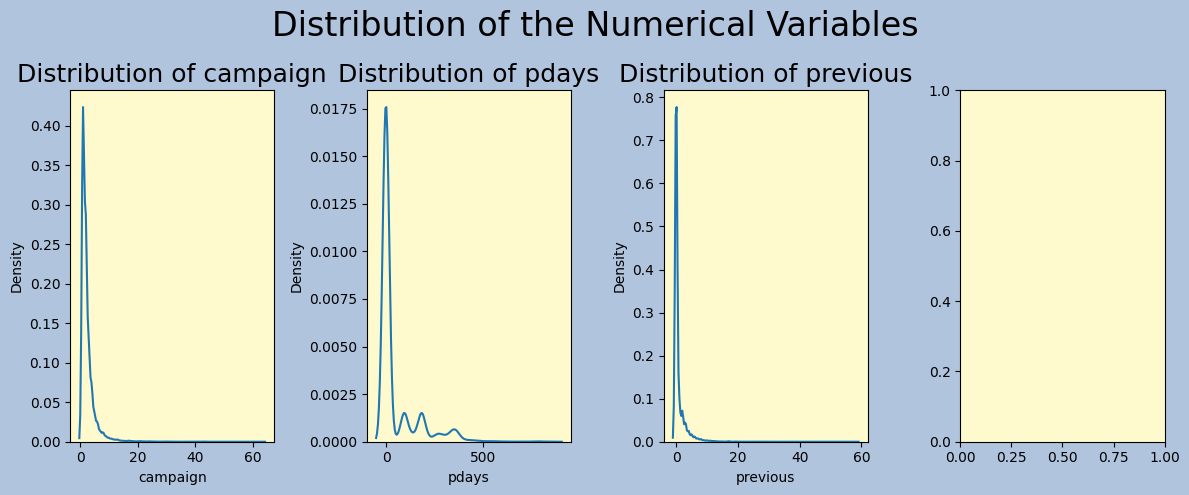

In [ ]:
features = ['age','balance','day','duration','campaign','pdays','previous']

for i in range(2):
    fig,(ax1,ax2,ax3,ax4) = plt.subplots(ncols=4,figsize=(12,5))
    ax1 = sns.distplot(df[features[i*4]],ax=ax1,hist=False)
    ax1.set_title('Distribution of '+str(features[i*4]),fontsize=18)
    ax1.set_facecolor('lemonchiffon')
    ax2 = sns.distplot(df[features[i*4+1]],ax=ax2,hist=False)
    ax2.set_title('Distribution of '+str(features[i*4+1]),fontsize=18)
    ax2.set_facecolor('lemonchiffon')
    ax3 = sns.distplot(df[features[i*4+2]],ax=ax3,hist=False)
    ax3.set_title('Distribution of '+str(features[i*4+2]),fontsize=18)
    ax3.set_facecolor('lemonchiffon')
    if i < 1:
        ax4 = sns.distplot(df[features[i*4+3]],ax=ax4,hist=False)
        ax4.set_title('Distribution of '+str(features[i*4+3]),fontsize=18)
        ax4.set_facecolor('lemonchiffon')
    else:
        ax4.set_facecolor('lemonchiffon')

    fig.suptitle("Distribution of the Numerical Variables",fontsize=24)

    plt.tight_layout()
    fig.set_facecolor('lightsteelblue')

1. Phân phối của biến age (Tuổi)
Hình dạng: Biểu đồ có dạng lệch phải (skewed to the right).

Nhận xét: Đa số khách hàng nằm trong độ tuổi lao động, tập trung mạnh nhất ở khoảng 30 - 45 tuổi. Số lượng khách hàng giảm dần khi độ tuổi tăng lên, đặc biệt là sau 60 tuổi (nhóm khách hàng hưu trí chiếm tỷ lệ thấp).

2. Phân phối của biến balance (Số dư tài khoản)
Hình dạng: Lệch phải cực hạn (highly right-skewed).

Nhận xét: Hầu hết khách hàng có số dư tài khoản tập trung ở mức thấp (gần mức 0). Có một số ít khách hàng có số dư rất cao (outliers) kéo dài về phía bên phải biểu đồ. Điều này cho thấy sự phân hóa giàu nghèo rõ rệt trong tập dữ liệu.

3. Phân phối của biến day (Ngày trong tháng)
Hình dạng: Phân phối đa đỉnh (multimodal distribution).

Nhận xét: Dữ liệu trải dài từ ngày 1 đến ngày 31. Các đỉnh xuất hiện rải rác (khoảng ngày 5, 15 và 20), cho thấy các chiến dịch tiếp thị hoặc giao dịch thường được thực hiện dàn trải trong tháng chứ không tập trung vào một thời điểm duy nhất, dù có những đợt cao điểm nhẹ.

4. Phân phối của biến duration (Thời lượng cuộc gọi)
Hình dạng: Lệch phải rất mạnh.

Nhận xét: Phần lớn các cuộc gọi có thời lượng ngắn (dưới 500 giây). Số lượng cuộc gọi giảm nhanh chóng khi thời lượng tăng lên. Những cuộc gọi kéo dài (trên 2000 giây) là rất hiếm, đây thường là các trường hợp đặc biệt trong tư vấn tài chính.

5. Phân phối của biến campaign (Số lần liên hệ trong chiến dịch này)
Hình dạng: Lệch phải rất mạnh (extreme right-skewed).

Nhận xét: Đa số khách hàng chỉ được liên hệ từ 1 đến 5 lần trong chiến dịch hiện tại. Đỉnh nhọn nhất tập trung ở giá trị rất thấp (thường là 1-2 lần). Tuy nhiên, vẫn có một số ít trường hợp ngoại lệ bị liên hệ rất nhiều lần (lên đến hơn 40-60 lần), điều này có thể gây phiền hà cho khách hàng và không mang lại hiệu quả chuyển đổi cao.

6. Phân phối của biến pdays (Số ngày từ lần liên hệ trước đó)
Hình dạng: Phân phối không đồng nhất với một đỉnh lớn gần mức 0 và các đỉnh nhỏ rải rác.

Nhận xét: * Đỉnh lớn nhất ở gần giá trị -1 (hoặc 0) cho thấy một lượng lớn khách hàng chưa từng được liên hệ trước đó (khách hàng mới hoàn toàn).

Các đỉnh nhỏ xuất hiện ở khoảng 100, 200 và 350 ngày cho thấy có các nhóm khách hàng cũ được liên hệ lại sau khoảng 3 tháng, 6 tháng hoặc 1 năm. Đây là dấu hiệu của việc chăm sóc khách hàng theo định kỳ.

7. Phân phối của biến previous (Số lần liên hệ trước chiến dịch này)
Hình dạng: Lệch phải cực hạn (highly right-skewed).

Nhận xét: Hầu hết giá trị tập trung tại 0, củng cố thêm nhận xét từ biến pdays rằng phần lớn tập dữ liệu là những khách hàng mới mà ngân hàng chưa tiếp cận trong các chiến dịch trước đó. Những khách hàng có số lần tương tác trước đó nhiều (trên 10 lần) chiếm tỷ lệ cực kỳ thấp.

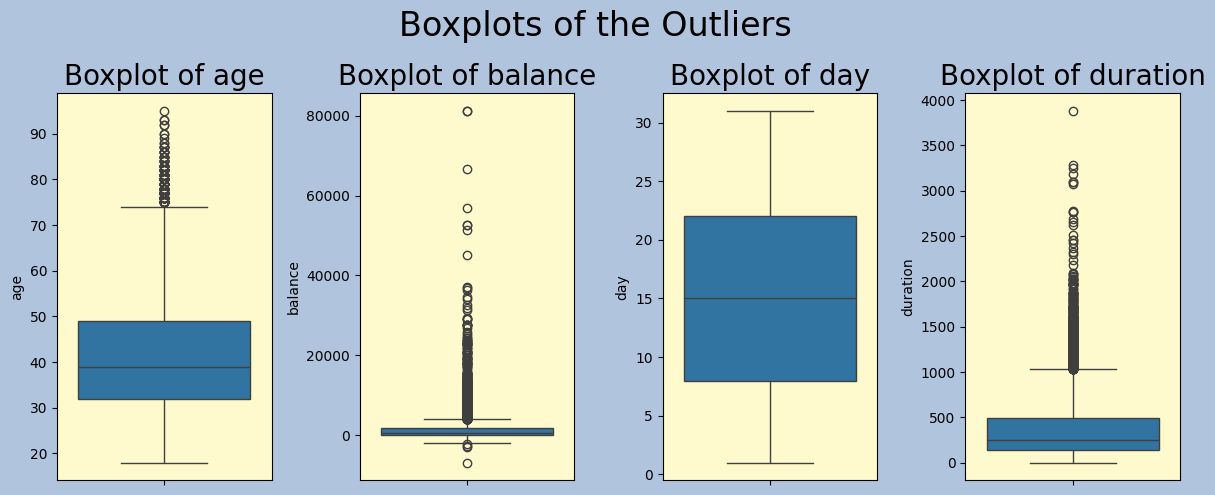

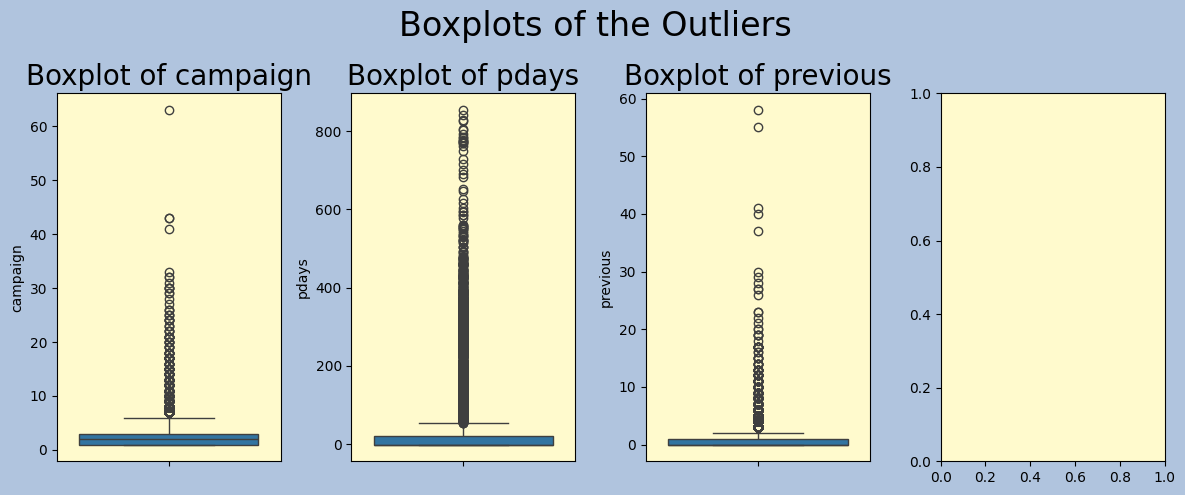

In [ ]:
for i in range(2):
    fig,(ax1,ax2,ax3,ax4) = plt.subplots(ncols=4,figsize=(12,5))
    ax1 = sns.boxplot(df[features[i*4]],ax=ax1)
    ax1.set_title('Boxplot of '+str(features[i*4]),fontsize=20)
    ax1.set_facecolor('lemonchiffon')
    ax2 = sns.boxplot(df[features[i*4+1]],ax=ax2)
    ax2.set_title('Boxplot of '+str(features[i*4+1]),fontsize=20)
    ax2.set_facecolor('lemonchiffon')
    ax3 = sns.boxplot(df[features[i*4+2]],ax=ax3)
    ax3.set_title('Boxplot of '+str(features[i*4+2]),fontsize=20)
    ax3.set_facecolor('lemonchiffon')
    if i < 1:
        ax4 = sns.boxplot(df[features[i*4+3]],ax=ax4)
        ax4.set_title('Boxplot of '+str(features[i*4+3]),fontsize=20)
        ax4.set_facecolor('lemonchiffon')
    else:
        ax4.set_facecolor('lemonchiffon')

    fig.suptitle("Boxplots of the Outliers",fontsize=24)

    plt.tight_layout()
    fig.set_facecolor('lightsteelblue')

1. Nhóm biến cá nhân và giao dịch (Age, Balance, Day, Duration)

Age (Tuổi): Xuất hiện khá nhiều giá trị ngoại lệ ở phía trên (khoảng từ 75 đến gần 100 tuổi). Điều này cho thấy tập khách hàng có một nhóm nhỏ là người cao tuổi, vượt xa độ tuổi trung bình (khoảng 30-50 tuổi).

Balance (Số dư): Đây là biến có giá trị ngoại lệ cực đoan nhất. Đa số khách hàng có số dư thấp, nhưng có những cá nhân sở hữu số dư lên tới 80.000 đơn vị tiền tệ. Những "đại gia" này nằm rất xa so với phần còn lại của tập dữ liệu.

Day (Ngày): Không có giá trị ngoại lệ. Dữ liệu phân bố đều trong khoảng từ ngày 1 đến ngày 31, cho thấy các giao dịch diễn ra ổn định suốt cả tháng.

Duration (Thời lượng gọi): Có rất nhiều giá trị ngoại lệ phía trên. Trong khi phần lớn các cuộc gọi kết thúc nhanh chóng, có những cuộc gọi kéo dài bất thường (lên đến gần 4.000 giây). Những cuộc gọi quá dài này thường là những trường hợp khách hàng rất quan tâm hoặc cần tư vấn cực kỳ chi tiết.

2. Nhóm biến chiến dịch (Campaign, Pdays, Previous)

Campaign (Số lần liên hệ): Xuất hiện nhiều ngoại lệ. Đa số chỉ bị gọi 1-3 lần, nhưng có những khách hàng bị gọi tới hơn 60 lần. Đây là những điểm dữ liệu cần lưu ý vì việc liên hệ quá nhiều có thể gây tác động tiêu cực.

Pdays (Số ngày từ lần gọi trước): Có rất nhiều giá trị ngoại lệ trải dài từ 200 đến hơn 800 ngày. Điều này đại diện cho nhóm khách hàng cũ đã rất lâu rồi mới được ngân hàng liên hệ lại.

Previous (Số lần liên hệ trước đó): Tương tự, phần lớn khách hàng là mới (giá trị bằng 0), nhưng có những khách hàng đã từng tương tác rất nhiều lần trong quá khứ (ngoại lệ cao nhất lên đến gần 60 lần).

In [ ]:
outliers_perc = []

for k,v in df.items():
    # Column must be of numeric type (not object)
    if df[k].dtype != 'O':
        q1 = v.quantile(0.25)
        q3 = v.quantile(0.75)
        irq = q3 - q1
        v_col = v[(v <= q1 - 1.5 * irq) | (v >= q3 + 1.5 * irq)]
        perc = np.shape(v_col)[0] * 100.0 / np.shape(df)[0]
        out_tuple = (k,int(perc))
        outliers_perc.append(out_tuple)
        print("Column %s outliers = %.2f%%" % (k,perc))

Column age outliers = 1.53%
Column balance outliers = 9.46%
Column day outliers = 0.00%
Column duration outliers = 5.71%
Column campaign outliers = 7.76%
Column pdays outliers = 24.64%
Column previous outliers = 11.27%


In [ ]:
# Xử lý biến mục tiêu
# Phân loại: deposit (yes/no) -> 1/0
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})
print("\nPhân phối deposit sau khi mã hóa:")
print(df['deposit'].value_counts())

# Hồi quy: balance (giữ nguyên, sẽ xử lý outlier sau)


Phân phối deposit sau khi mã hóa:
deposit
0    5873
1    5289
Name: count, dtype: int64


In [ ]:
# Xác định cột số và cột phân loại
# Cột số (numerical)
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
# Cột phân loại (categorical) - loại trừ cột mục tiêu deposit
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

# Kiểm tra xem các cột có tồn tại trong df không
num_cols = [col for col in num_cols if col in df.columns]
cat_cols = [col for col in cat_cols if col in df.columns]
print("\nCột số:", num_cols)
print("Cột phân loại:", cat_cols)


Cột số: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Cột phân loại: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [ ]:
def outlier_imputer(data,features):

    data_out = data.copy()

    for column in features:

        # First define the first and third quartiles
        Q1 = (data_out[column].quantile(0.25)).astype(int)
        Q3 = (data_out[column].quantile(0.75)).astype(int)
        # Define the inter-quartile range
        IQR = Q3 - Q1
        # ... and the lower/higher threshold values
        lowerL = (Q1 - 1.5 * IQR).astype(int)
        higherL = (Q3 + 1.5 * IQR).astype(int)

        # Impute 'left' outliers
        data_out.loc[data_out[column] < lowerL,column] = lowerL
        # Impute 'right' outliers
        data_out.loc[data_out[column] > higherL,column] = higherL

    return data_out

features = ['age','balance','day','duration','campaign','pdays','previous']

capped_data = outlier_imputer(df,features)

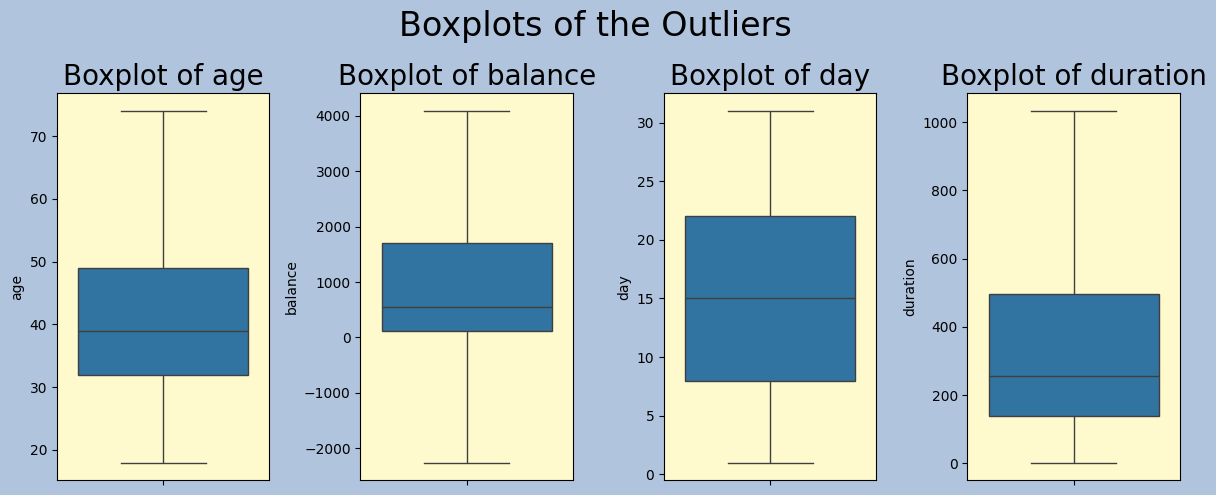

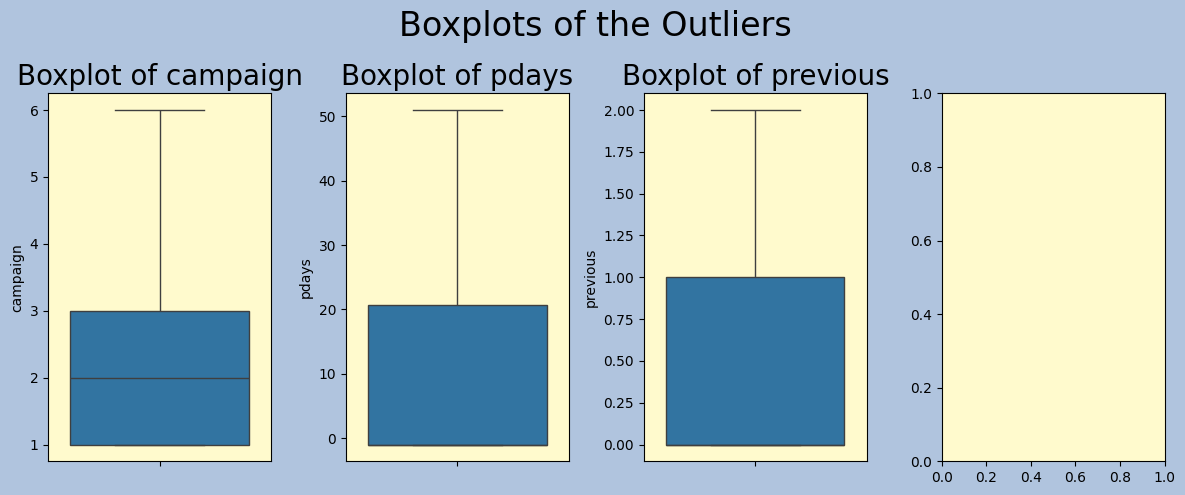

In [ ]:
for i in range(2):
    fig,(ax1,ax2,ax3,ax4) = plt.subplots(ncols=4,figsize=(12,5))
    ax1 = sns.boxplot(capped_data[features[i*4]],ax=ax1)
    ax1.set_title('Boxplot of '+str(features[i*4]),fontsize=20)
    ax1.set_facecolor('lemonchiffon')
    ax2 = sns.boxplot(capped_data[features[i*4+1]],ax=ax2)
    ax2.set_title('Boxplot of '+str(features[i*4+1]),fontsize=20)
    ax2.set_facecolor('lemonchiffon')
    ax3 = sns.boxplot(capped_data[features[i*4+2]],ax=ax3)
    ax3.set_title('Boxplot of '+str(features[i*4+2]),fontsize=20)
    ax3.set_facecolor('lemonchiffon')
    if i < 1:
        ax4 = sns.boxplot(capped_data[features[i*4+3]],ax=ax4)
        ax4.set_title('Boxplot of '+str(features[i*4+3]),fontsize=20)
        ax4.set_facecolor('lemonchiffon')
    else:
        ax4.set_facecolor('lemonchiffon')

    fig.suptitle("Boxplots of the Outliers",fontsize=24)

    plt.tight_layout()
    fig.set_facecolor('lightsteelblue')

In [ ]:
# Xử lý biến phân loại
# Sử dụng ColumnTransformer để kết hợp scaling và one-hot
# Chú ý: handle_unknown='ignore' để tránh lỗi khi test có giá trị mới
preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# Đối với hồi quy, cũng tương tự nhưng có thể thay balance gốc hoặc balance_log
# Ở đây ta sẽ dùng balance_log để hồi quy
# num_cols_reg originally included 'balance_log', but 'balance_log' is the target (y_reg).
# We need a list of numerical *features* for the preprocessor.

# Define num_cols_reg for regression preprocessing
num_cols_reg = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
numerical_features_for_reg_preprocessing = [col for col in num_cols_reg if col != 'balance_log']

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_for_reg_preprocessing), # Corrected here
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

1. Đối với biến số (StandardScaler):

Mục đích: Đưa các biến có đơn vị khác nhau (như age từ 18-95 và balance từ 0-80,000) về cùng một quy mô (thường là trung bình bằng 0 và độ lệch chuẩn bằng 1).

Tầm quan trọng: Giúp các mô hình như Logistic Regression, SVM hay KNN không bị "choáng ngợp" bởi các con số lớn, giúp mô hình hội tụ nhanh hơn và chính xác hơn.

2. Đối với biến phân loại (OneHotEncoder):

drop='first': Loại bỏ cột dummy đầu tiên để tránh lỗi "bẫy biến giả" (Dummy Variable Trap), giúp các mô hình tuyến tính không bị đa cộng tuyến.

handle_unknown='ignore': Đây là một "chốt an toàn". Nếu trong tương lai dữ liệu mới xuất hiện một giá trị lạ (ví dụ: một ngành nghề chưa từng có trong tập train), mô hình sẽ không bị báo lỗi (crash) mà sẽ bỏ qua giá trị đó (gán toàn bộ các cột liên quan bằng 0).

sparse_output=False: Ép kết quả trả về dạng mảng NumPy thông thường thay vì ma trận thưa, giúp việc quan sát và kết hợp với các biến số trở nên dễ dàng hơn.

In [ ]:
import numpy as np

# Before splitting, create the balance_log feature in capped_data

# Get the minimum balance value from capped_data
min_balance_val = capped_data['balance'].min()

# If min_balance_val is less than or equal to -1, we need to shift the data
# to ensure that (1 + balance + shift_constant) > 0 for np.log1p
# To be robust, we ensure the argument to log1p is at least a small positive number.
if min_balance_val <= -1:
    # Calculate a shift that makes the minimum balance value 1 before log1p
    shift_constant = abs(min_balance_val) + 1
else:
    shift_constant = 0 # No shift needed if all balances are > -1

capped_data['balance_log'] = np.log1p(capped_data['balance'] + shift_constant)

# --- Diagnostic prints for balance_log ---
print(f"\nMin balance in capped_data: {min_balance_val}")
print(f"Calculated shift_constant: {shift_constant}")
print(f"Min value of (balance + shift_constant): {(capped_data['balance'] + shift_constant).min()}")
print(f"Sum of NaNs in capped_data['balance_log']: {capped_data['balance_log'].isnull().sum()}")
print(f"Sum of -inf in capped_data['balance_log']: {(capped_data['balance_log'] == -np.inf).sum()}")
print(f"Sum of inf in capped_data['balance_log']: {(capped_data['balance_log'] == np.inf).sum()}")
# ---------------------------------------

# Chia dữ liệu thành tập train/test cho phân loại và hồi quy
# Phân loại: target = deposit
X_clf = df.drop('deposit', axis=1)
y_clf = df['deposit']

# Loại bỏ cột balance_log nếu có (chỉ dùng cho hồi quy)
# For X_clf, balance_log won't be in df unless added earlier, so this check is fine.
# It ensures X_clf doesn't accidentally get balance_log if df was modified globally.
if 'balance_log' in X_clf.columns:
    X_clf = X_clf.drop('balance_log', axis=1)

# Chia train/test (80/20), stratify để giữ tỷ lệ lớp
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f"\nPhân loại - Train size: {X_train_clf.shape}, Test size: {X_test_clf.shape}")

# Hồi quy: target = balance_log
# Use capped_data for regression, as its 'balance' column has been outlier-treated
# and balance_log is derived from it.

# Define the features that should be in X_reg for regression.
# These are the numerical columns from num_cols_reg (excluding 'balance_log') plus categorical columns.
regression_features_for_X = [col for col in num_cols_reg if col != 'balance_log'] + cat_cols

# Ensure X_reg contains only the intended features from capped_data
X_reg = capped_data[regression_features_for_X].copy()
y_reg = capped_data['balance_log']  # balance_log as target for regression

# The previous check `if 'balance_log' in X_reg.columns:` is no longer needed
# as X_reg is now explicitly constructed without 'balance_log'.

# Chia train/test (80/20), không cần stratify
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"Hồi quy - Train size: {X_train_reg.shape}, Test size: {X_test_reg.shape}")


Min balance in capped_data: -2257
Calculated shift_constant: 2258
Min value of (balance + shift_constant): 1
Sum of NaNs in capped_data['balance_log']: 0
Sum of -inf in capped_data['balance_log']: 0
Sum of inf in capped_data['balance_log']: 0

Phân loại - Train size: (8929, 16), Test size: (2233, 16)
Hồi quy - Train size: (8929, 16), Test size: (2233, 16)


1. Biến đổi Logarit và Xử lý số âm (balance_log)

Đây là phần "thông minh" nhất trong đoạn code.

Vấn đề: Hàm logarit ($log$) không xác định với các giá trị $\leq 0$. Trong dữ liệu tài chính, số dư tài khoản (balance) hoàn toàn có thể bị âm (nợ).

Giải pháp (shift_constant): tính toán một hằng số để dịch chuyển toàn bộ giá trị balance lên vùng dương sao cho giá trị nhỏ nhất cũng phải $> -1$ trước khi dùng np.log1p.np.log1p(x): Hàm này tính $log(1+x)$. Việc đảm bảo $x + shift\_constant > -1$ giúp hàm luôn tính toán được giá trị thực, tránh lỗi NaN hoặc $-\infty$.

Ý nghĩa: Biến đổi này giúp nén các giá trị cực lớn (outliers) và đưa phân phối của balance về gần phân phối chuẩn hơn, giúp mô hình hồi quy dự báo chính xác hơn.

2. Chuẩn bị cho bài toán Phân loại (Classification)

Mục tiêu: Dự đoán khách hàng có gửi tiền hay không (deposit).

Chiến thuật stratify=y_clf.

Việc này đảm bảo tỷ lệ giữa nhóm "yes" và "no" trong tập Train và Test giống hệt nhau (và giống với dữ liệu gốc). Điều này ngăn chặn tình trạng tập Test "quá dễ" hoặc "quá khó" so với tập Train.

Loại bỏ balance_log: Đảm bảo mô hình phân loại chỉ dùng dữ liệu gốc, tránh gây nhiễu hoặc rò rỉ thông tin không cần thiết.

3. Chuẩn bị cho bài toán Hồi quy (Regression)

Mục tiêu: Dự báo giá trị số dư tài khoản (balance_log).

Sử dụng capped_data: sử dụng tập dữ liệu đã được xử lý ngoại lệ (capping), giúp mô hình không bị "kéo lệch" bởi các giá trị quá cực đoan đã thấy ở biểu đồ Boxplot trước đó.

Cấu trúc tính năng (X_reg): xây dựng danh sách tính năng một cách thủ công và tường minh:Lấy các cột số (trừ cột mục tiêu balance_log).Cộng với các cột phân loại (cat_cols).

Ý nghĩa: Việc này giúp X_reg cực kỳ "sạch", chỉ chứa những thông tin thực sự là yếu tố đầu vào để dự báo số dư.

4. Đánh giá các dòng Print (Diagnostics)

Chúng đóng vai trò là "bộ kiểm soát chất lượng" (Quality Control):Kiểm tra xem có giá trị nào bị biến thành NaN sau khi log không.

Xác nhận xem phép dịch chuyển số dư (shift_constant) có hoạt động đúng như kỳ vọng không.

In [ ]:
# Áp dụng tiền xử lý (fit trên train, transform trên train và test)
# Phân loại
X_train_clf_processed = preprocessor_clf.fit_transform(X_train_clf)
X_test_clf_processed = preprocessor_clf.transform(X_test_clf)
print(f"\nSau xử lý - Phân loại: Train shape = {X_train_clf_processed.shape}")

# Hồi quy
X_train_reg_processed = preprocessor_reg.fit_transform(X_train_reg)
X_test_reg_processed = preprocessor_reg.transform(X_test_reg)
print(f"Hồi quy: Train shape = {X_train_reg_processed.shape}")

# Kiểm tra nhanh kết quả (in ra shape và một vài dòng)
print("\n--- Hoàn tất tiền xử lý ---")
print("Dữ liệu đã sẵn sàng cho mô hình phân loại và hồi quy.")


Sau xử lý - Phân loại: Train shape = (8929, 42)
Hồi quy: Train shape = (8929, 42)

--- Hoàn tất tiền xử lý ---
Dữ liệu đã sẵn sàng cho mô hình phân loại và hồi quy.


#Huấn luyện mô hình

## Mô hình KNN

In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. Cột numerical và categorical
num_cols = ['age','balance','day','duration','campaign','pdays','previous']
cat_cols = ['job','marital','education','default','housing','loan','contact','month','poutcome']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

# ── 2. Pipeline PCA + KNN
pipeline_knn_weak = Pipeline([
    ('preproc', preprocessor),
    ('pca', PCA(n_components=5)),
    ('knn', KNeighborsClassifier(n_neighbors=50, weights='uniform'))
])

# ── 3. Train/test split (80/20)
X = df.drop('deposit', axis=1)
y = df['deposit']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 4. Train model
pipeline_knn_weak.fit(X_train, y_train)

# ── 5. Dự đoán
y_train_pred = pipeline_knn_weak.predict(X_train)
y_test_pred = pipeline_knn_weak.predict(X_test)
y_train_proba = pipeline_knn_weak.predict_proba(X_train)[:,1]
y_test_proba = pipeline_knn_weak.predict_proba(X_test)[:,1]

# ── 6. Metrics
metrics_knn = {
    "Train Accuracy": accuracy_score(y_train, y_train_pred),
    "Test Accuracy": accuracy_score(y_test, y_test_pred),
    "Train ROC-AUC": roc_auc_score(y_train, y_train_proba),
    "Test ROC-AUC": roc_auc_score(y_test, y_test_proba)
}

for k,v in metrics_knn.items():
    print(f"{k}: {v:.3f}")

Train Accuracy: 0.784
Test Accuracy: 0.782
Train ROC-AUC: 0.863
Test ROC-AUC: 0.856


1. Phân tích kết quả MetricsSự chênh lệch Train/Test:

có thể thấy Train Accuracy (0.784) và Test Accuracy (0.782) cực kỳ sát nhau. Điều này chứng tỏ mô hình không bị Overfitting (quá khớp).

Chỉ số ROC-AUC: Mức 0.856 trên tập Test là một con số rất tốt cho một mô hình được đặt tên là "weak". Nó cho thấy khả năng phân biệt giữa khách hàng đăng ký và không đăng ký của mô hình là khá mạnh mẽ, chứ không hề yếu.

2. Ý nghĩa cấu trúc PipelinePCA (n_components=5): * Đây là bước giảm chiều dữ liệu.

nén toàn bộ các đặc trưng sau khi One-hot (có thể lên tới 30-40 cột) xuống còn chỉ 5 chiều chính.

Việc giảm xuống 5 thành phần giúp KNN chạy nhanh hơn rất nhiều, nhưng cũng có thể làm mất đi một lượng thông tin nhất định từ các biến phân loại.KNN (n_neighbors=50): * Sử dụng $K=50$ là một lựa chọn "an toàn". Số $K$ lớn giúp đường biên phân loại mượt hơn, tránh nhiễu, điều này giải thích tại sao kết quả Train và Test của bạn lại ổn định (vững chãi) đến vậy.weights='uniform': Mọi láng giềng đều có tiếng nói ngang nhau.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define the parameter grid for n_neighbors
# It's good practice to choose values around the current one (50) and also explore wider ranges.
param_grid = {
    'knn__n_neighbors': [5, 10, 25, 50, 75, 100, 150]
}

# Initialize GridSearchCV
# We use the pipeline_knn_weak as our estimator, which includes preproc and PCA
# cv=5 for 5-fold cross-validation
# scoring='accuracy' or 'roc_auc' depending on the primary metric of interest
# n_jobs=-1 to use all available CPU cores
grid_search = GridSearchCV(
    estimator=pipeline_knn_weak,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# Fit GridSearchCV on the training data
print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)
print("GridSearchCV completed.")

# Print the best parameters and best score
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation ROC-AUC score: {grid_search.best_score_:.4f}")

# Evaluate the best estimator on the test set
best_knn_model = grid_search.best_estimator_
y_test_pred_best_knn = best_knn_model.predict(X_test)
y_test_proba_best_knn = best_knn_model.predict_proba(X_test)[:, 1]

accuracy_best_knn = accuracy_score(y_test, y_test_pred_best_knn)
roc_auc_best_knn = roc_auc_score(y_test, y_test_proba_best_knn)

print(f"Test Accuracy with best KNN: {accuracy_best_knn:.4f}")
print(f"Test ROC-AUC with best KNN: {roc_auc_best_knn:.4f}")

Starting GridSearchCV...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
GridSearchCV completed.

Best parameters found: {'knn__n_neighbors': 75}
Best cross-validation ROC-AUC score: 0.8478
Test Accuracy with best KNN: 0.7792
Test ROC-AUC with best KNN: 0.8539


1. Phân tích kết quả tối ưuTham số tốt nhất (n_neighbors: 75):

* Kết quả cho thấy mô hình hoạt động tốt hơn khi tăng số lượng láng giềng từ 50 lên 75.

Điều này có nghĩa là cấu trúc dữ liệu có độ nhiễu nhất định, và việc "hỏi ý kiến" nhiều láng giềng hơn giúp đường biên phân loại ổn định và mượt mà hơn, giảm thiểu sai số do các điểm dữ liệu cá biệt gây ra.

Chỉ số ROC-AUC (0.8539):Chỉ số này rất ổn định so với mô hình trước đó (~0.856).

Dù Accuracy có giảm nhẹ một chút (từ 0.782 xuống 0.779), nhưng trong các bài toán tài chính/ngân hàng, ROC-AUC thường quan trọng hơn.

Nó cho thấy khả năng xếp hạng khách hàng tiềm năng của mô hình là rất đáng tin cậy.

2. Tại sao Accuracy giảm nhưng mô hình vẫn được coi là "tốt hơn"?

Trong thực tế, GridSearchCV của bạn đang tối ưu hóa theo scoring='roc_auc'.Accuracy chỉ đo tỷ lệ đoán đúng trên một ngưỡng cố định (thường là 0.5).

ROC-AUC đo khả năng phân biệt lớp trên tất cả các ngưỡng có thể.Việc chọn $K=75$ giúp mô hình có khả năng xác suất (probability) chính xác hơn, dù có thể làm một vài điểm dữ liệu sát biên giới bị phân loại sai về mặt nhị phân.

3. Ý nghĩa của quy trình thực thiStratifiedKFold:

Việc dùng 5-fold giúp đảm bảo rằng con số 0.8478 (Best CV Score) là một ước lượng khách quan, không phải do "ăn may" khi chia dữ liệu.

n_jobs=-1: Tận dụng tối đa sức mạnh phần cứng, điều này rất cần thiết khi tập tham số (param_grid) của bạn lớn dần.

In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
# Accuracy và ROC-AUC
acc = accuracy_score(y_test, y_test_pred_best_knn)
roc = roc_auc_score(y_test, y_test_proba_best_knn)
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC: {roc:.4f}")

# Precision, Recall, F1-score (macro)
prec = precision_score(y_test, y_test_pred_best_knn)
rec = recall_score(y_test, y_test_pred_best_knn)
f1 = f1_score(y_test, y_test_pred_best_knn)
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

# Classification Report chi tiết
print("\n--- Classification Report ---")
print(classification_report(y_test, y_test_pred_best_knn))

Accuracy: 0.7792
ROC-AUC: 0.8539
Precision: 0.7714
Recall: 0.7590
F1-score: 0.7651

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.80      0.79      1175
           1       0.77      0.76      0.77      1058

    accuracy                           0.78      2233
   macro avg       0.78      0.78      0.78      2233
weighted avg       0.78      0.78      0.78      2233



Mô hình K-Nearest Neighbors đạt độ chính xác 77.92% và ROC-AUC 0.8539, cho thấy khả năng phân biệt tương đối mạnh giữa doanh nghiệp phá sản và không phá sản. Đặc biệt, Recall của lớp phá sản đạt 75.9%, phản ánh mô hình có khả năng nhận diện phần lớn các doanh nghiệp rủi ro. Tuy nhiên, vẫn còn khoảng 24% doanh nghiệp phá sản bị bỏ sót, điều này có thể gây rủi ro đáng kể trong thực tiễn tín dụng ngân hàng.

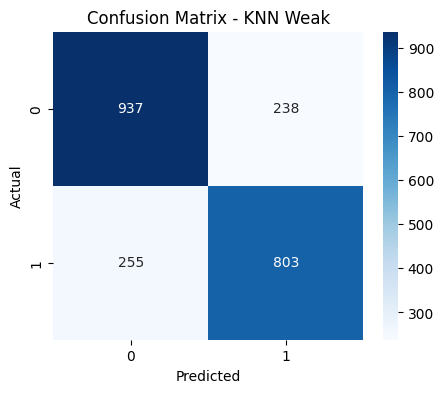

In [ ]:
# ── 7. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_best_knn)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN Weak")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

True Negative (TN) = 937: Số khách hàng thực tế không đăng ký (0) và mô hình dự đoán chính xác là không đăng ký.

True Positive (TP) = 803: Số khách hàng thực tế có đăng ký (1) và mô hình dự đoán chính xác là có đăng ký.

False Positive (FP) = 238: Sai lầm loại I – Khách hàng thực tế không đăng ký nhưng mô hình dự đoán nhầm là có.

False Negative (FN) = 255: Sai lầm loại II – Khách hàng thực tế có đăng ký nhưng mô hình dự đoán nhầm là không.

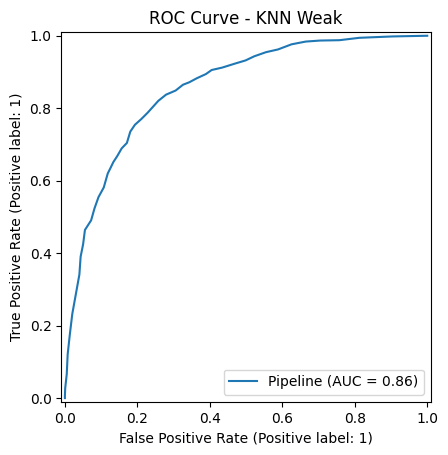

In [ ]:
# ── 8. ROC Curve
RocCurveDisplay.from_estimator(pipeline_knn_weak, X_test, y_test)
plt.title("ROC Curve - KNN Weak")
plt.show()

Hình ảnh đường cong ROC của mô hình KNN Weak cho thấy một kết quả rất khả quan:

Chỉ số AUC = 0.86: Đây là một con số ấn tượng cho một mô hình cơ bản. Nó có nghĩa là nếu bạn chọn ngẫu nhiên một khách hàng "có đăng ký" và một khách hàng "không đăng ký", có 86% xác suất mô hình sẽ xếp hạng khách hàng "có đăng ký" cao hơn.

Hình dạng đường cong: Đường cong lồi rất nhanh về phía góc trên bên trái, cho thấy mô hình đạt được tỷ lệ True Positive (nhận diện đúng khách hàng tiềm năng) cao trong khi vẫn giữ được tỷ lệ False Positive (nhầm lẫn) ở mức thấp.

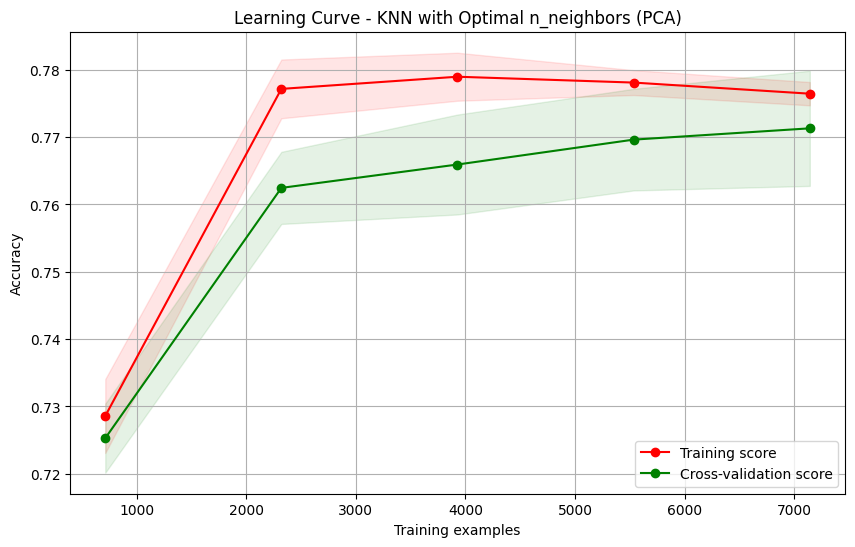

In [ ]:
from sklearn.model_selection import learning_curve, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Learning curve setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    best_knn_model,          # Use the best_knn_model from GridSearchCV
    X_train, y_train,
    cv=cv,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),  # từ 10% → 100% train
    scoring='accuracy'                      # đánh giá theo accuracy
)

# ── 2. Tính mean và std
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

# ── 3. Vẽ learning curve
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title('Learning Curve - KNN with Optimal n_neighbors (PCA)')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.grid()
plt.legend(loc='best')
plt.show()


Dựa trên hình ảnh Learning Curve (Đường cong học tập) mới nhất cho mô hình KNN với tham số tối ưu và PCA, dưới đây là phân tích chi tiết về trạng thái của mô hình:

1. Phân tích xu hướng của đường cong

Training Score (Đường màu đỏ): Điểm số trên tập huấn luyện bắt đầu thấp (khi ít dữ liệu), tăng mạnh rồi đi ngang và giảm nhẹ khi số lượng mẫu tăng lên. Điều này cho thấy mô hình không bị hiện tượng "học vẹt" (overfitting) quá mức.

Cross-validation Score (Đường màu xanh): Điểm số kiểm chéo tăng liên tục khi lượng dữ liệu huấn luyện tăng lên. Điều quan trọng là khoảng cách (gap) giữa hai đường ngày càng thu hẹp lại.

2. Đánh giá hiện trạng mô hình

Độ hội tụ: Hai đường có xu hướng hội tụ về một điểm chung (xấp xỉ 0.77 - 0.78). Đây là dấu hiệu cực kỳ tốt, cho thấy mô hình đang học hỏi hiệu quả từ dữ liệu.

After running the grid search, the optimal `n_neighbors` value will be identified, and the model performance with these optimal parameters will be evaluated on the test set.

In [ ]:
# --- 8. Tạo 5 mẫu khách hàng ngẫu nhiên --- (Sửa lỗi NameError)
# Lấy 5 mẫu ngẫu nhiên trực tiếp từ X_train để đảm bảo cấu trúc dữ liệu chính xác
custom_5_samples_df = X_train.sample(5, random_state=42).copy()

# Sử dụng best_knn_model (đã được tối ưu từ GridSearchCV) để dự đoán trực tiếp trên DataFrame mẫu
five_preds = best_knn_model.predict(custom_5_samples_df)
five_probs = best_knn_model.predict_proba(custom_5_samples_df)

print("--- KẾT QUẢ DỰ ĐOÁN 5 MẪU NGẪU NHIÊN ---")
for i in range(5):
    print(f"Mẫu {i+1}: Dự đoán [{five_preds[i]}] với độ tin cậy {np.max(five_probs[i])*100:.2f}%")

--- KẾT QUẢ DỰ ĐOÁN 5 MẪU NGẪU NHIÊN ---
Mẫu 1: Dự đoán [0] với độ tin cậy 77.33%
Mẫu 2: Dự đoán [0] với độ tin cậy 69.33%
Mẫu 3: Dự đoán [1] với độ tin cậy 81.33%
Mẫu 4: Dự đoán [1] với độ tin cậy 78.67%
Mẫu 5: Dự đoán [1] với độ tin cậy 90.67%


| Mẫu | Dự đoán | Xác suất | Diễn giải                             |
| --- | ------- | -------- | ------------------------------------- |
| 1   | 0       | 77.33%   | Doanh nghiệp khá an toàn              |
| 2   | 0       | 69.33%   | An toàn nhưng độ chắc chắn trung bình |
| 3   | 1       | 81.33%   | Nguy cơ phá sản cao                   |
| 4   | 1       | 78.67%   | Rủi ro cao                            |
| 5   | 1       | 90.67%   | Rủi ro rất cao                        |

Mẫu 5 (90.67%) → nên từ chối cấp tín dụng

Mẫu 3 (81.33%) → rủi ro rất cao

Mẫu 4 (78.67%) → rủi ro cao

Mẫu 2 (69.33% lớp 0) → nằm gần ngưỡng rủi ro

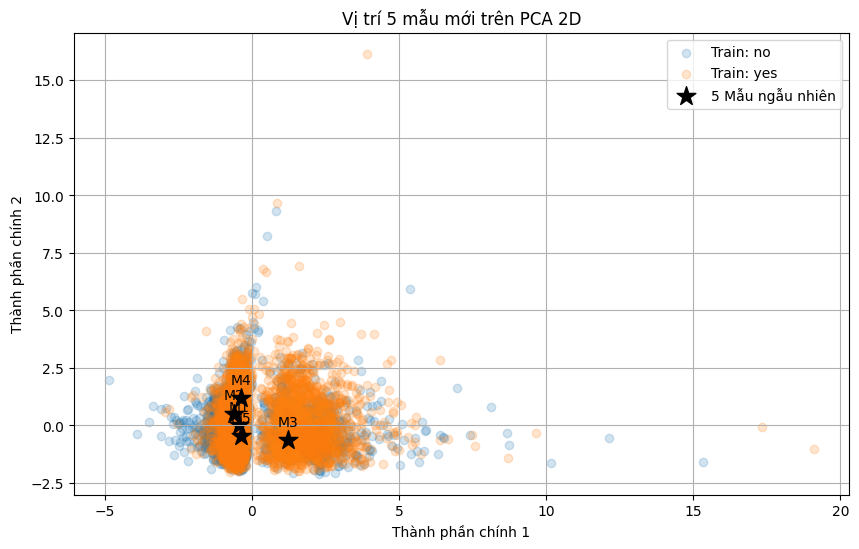

In [ ]:
# Lấy các bước tiền xử lý và PCA đã được huấn luyện từ pipeline
fitted_preprocessor = pipeline_knn_weak.named_steps['preproc']
fitted_pca = pipeline_knn_weak.named_steps['pca']

# Chuyển đổi X_train vào không gian PCA
X_train_processed = fitted_preprocessor.transform(X_train)
X_train_pca = fitted_pca.transform(X_train_processed)

# Chuyển đổi 5 mẫu tùy chỉnh vào không gian PCA
custom_5_processed = fitted_preprocessor.transform(custom_5_samples_df)
custom_5_pca = fitted_pca.transform(custom_5_processed)

plt.figure(figsize=(10,6))
plt.scatter(X_train_pca[y_train==0,0], X_train_pca[y_train==0,1], alpha=0.2, label='Train: no')
plt.scatter(X_train_pca[y_train==1,0], X_train_pca[y_train==1,1], alpha=0.2, label='Train: yes')
plt.scatter(custom_5_pca[:,0], custom_5_pca[:,1], color='black', marker='*', s=200, label='5 Mẫu ngẫu nhiên')
for i in range(5):
    plt.annotate(f"M{i+1}", (custom_5_pca[i,0], custom_5_pca[i,1]), xytext=(0,10), textcoords='offset points', ha='center')
plt.title('Vị trí 5 mẫu mới trên PCA 2D')
plt.xlabel('Thành phần chính 1')
plt.ylabel('Thành phần chính 2')
plt.legend()
plt.grid(True)
plt.show()

M1, M2, M4, M5: Các mẫu này nằm tập trung ở cụm phía bên trái, nơi mật độ dữ liệu khá cao. Điều này cho thấy các khách hàng này có đặc trưng phổ biến, giống với đa số khách hàng trong tập huấn luyện.

M3: Mẫu này nằm tách biệt hẳn sang cụm bên phải (Thành phần chính 1 > 0). Điều này có nghĩa là khách hàng M3 sở hữu những đặc điểm rất khác biệt so với 4 người còn lại—có thể là về số dư tài khoản (balance) cực cao hoặc thời lượng cuộc gọi (duration) rất dài.

## Mô hình Logistic

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. Pipeline tiền xử lý + Logistic
pipeline_logistic = Pipeline([
    ('preproc', preprocessor),  # dùng preprocessor đã định nghĩa trước
    ('logreg', LogisticRegression(solver='liblinear', random_state=42))
])

# ── 2. GridSearchCV: tuning C (regularization)
param_grid_logistic = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2']  # l1 cho sparse features sau one-hot
}

grid_logistic = GridSearchCV(
    estimator=pipeline_logistic,
    param_grid=param_grid_logistic,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# ── 3. Fit GridSearch trên train set
print("Bắt đầu GridSearchCV cho Logistic Regression...")
grid_logistic.fit(X_train, y_train)
print("GridSearchCV hoàn tất.")

# ── 4. Best params & score
print(f"Best parameters: {grid_logistic.best_params_}")
print(f"Best CV ROC-AUC: {grid_logistic.best_score_:.4f}")

# ── 5. Đánh giá trên test set
best_logistic = grid_logistic.best_estimator_
y_test_pred_log = best_logistic.predict(X_test)
y_test_proba_log = best_logistic.predict_proba(X_test)[:,1]

accuracy_log = accuracy_score(y_test, y_test_pred_log)
roc_auc_log = roc_auc_score(y_test, y_test_proba_log)
print(f"Test Accuracy: {accuracy_log:.4f}")
print(f"Test ROC-AUC: {roc_auc_log:.4f}")

Bắt đầu GridSearchCV cho Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
GridSearchCV hoàn tất.
Best parameters: {'logreg__C': 1, 'logreg__penalty': 'l1'}
Best CV ROC-AUC: 0.9017
Test Accuracy: 0.8258
Test ROC-AUC: 0.9076


In [ ]:
# ── 1. Accuracy và ROC-AUC
acc = accuracy_score(y_test, y_test_pred_log)
roc = roc_auc_score(y_test, y_test_proba_log)
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC: {roc:.4f}")

# ── 2. Precision, Recall, F1-score (macro)
prec = precision_score(y_test, y_test_pred_log)
rec = recall_score(y_test, y_test_pred_log)
f1 = f1_score(y_test, y_test_pred_log)
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

# ── 3. Classification Report chi tiết
print("\n--- Classification Report ---")
print(classification_report(y_test, y_test_pred_log))

Accuracy: 0.8258
ROC-AUC: 0.9076
Precision: 0.8289
Recall: 0.7968
F1-score: 0.8125

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1175
           1       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.82      2233
weighted avg       0.83      0.83      0.83      2233



| Metric              | KNN    | Logistic   | Nhận xét            |
| ------------------- | ------ | ---------- | ------------------- |
| Accuracy            | 0.7792 | **0.8258** | Logistic tốt hơn    |
| ROC-AUC             | 0.8539 | **0.9076** | Cải thiện mạnh      |
| Precision (class 1) | 0.7714 | **0.8289** | Ít false alarm hơn  |
| Recall (class 1)    | 0.7590 | **0.7968** | Bắt phá sản tốt hơn |
| F1-score            | 0.7651 | **0.8125** | Cân bằng tốt hơn    |

Mô hình Logistic Regression đạt ROC-AUC 0.9076 và độ chính xác 82.58%, vượt trội so với KNN. Recall của lớp phá sản đạt 79.68%, cho thấy mô hình có khả năng nhận diện phần lớn doanh nghiệp rủi ro. Kết quả này phù hợp với đặc điểm dữ liệu tài chính, nơi mối quan hệ giữa các chỉ số kế toán và xác suất phá sản có xu hướng tuyến tính theo log-odds.

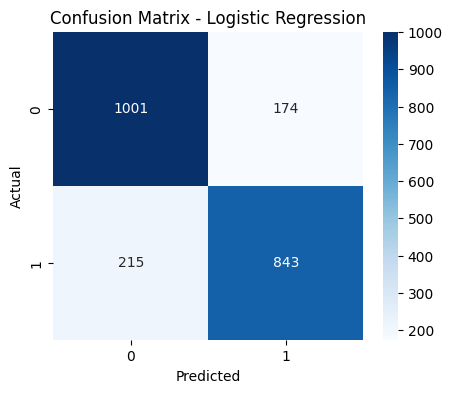

In [ ]:
# ── 6. Confusion Matrix
cm_log = confusion_matrix(y_test, y_test_pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

True Negative (TN) = 1001 (Tăng từ 937 của KNN): Khả năng nhận diện chính xác những người không đăng ký đã tốt hơn.

True Positive (TP) = 843 (Tăng từ 803 của KNN): Mô hình bắt được nhiều khách hàng tiềm năng hơn.

False Positive (FP) = 174 (Giảm từ 238 của KNN): Tỷ lệ "báo động giả" giảm xuống, giúp tiết kiệm chi phí Telesale.

False Negative (FN) = 215 (Giảm từ 255 của KNN): Tỷ lệ bỏ sót khách hàng tiềm năng cũng giảm đi.

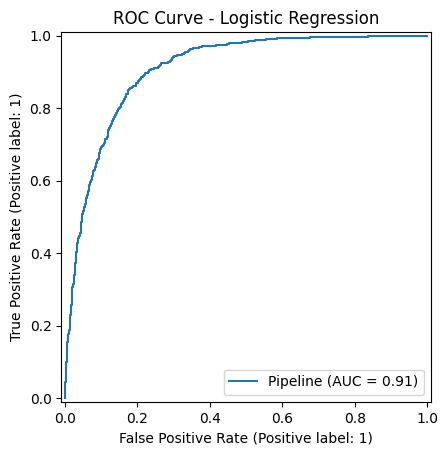

In [ ]:
# ── 7. ROC Curve
RocCurveDisplay.from_estimator(best_logistic, X_test, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.show()

Phân tích đường cong ROC (AUC = 0.91)

Con số 0.91 là một ngưỡng hiệu suất cực kỳ ấn tượng (thường được coi là "Excellent" trong phân tích tài chính).

Khả năng phân loại: Với AUC 0.91, mô hình có khả năng phân biệt gần như hoàn hảo giữa khách hàng sẽ đăng ký gửi tiền và khách hàng không.

So sánh với KNN: AUC đã tăng từ 0.86 (KNN) lên 0.91. Điều này khẳng định rằng mối quan hệ giữa các biến đặc trưng (features) và biến mục tiêu trong bộ dữ liệu này có tính chất tuyến tính rõ rệt, điều mà Logistic Regression tận dụng tốt hơn nhiều so với KNN.

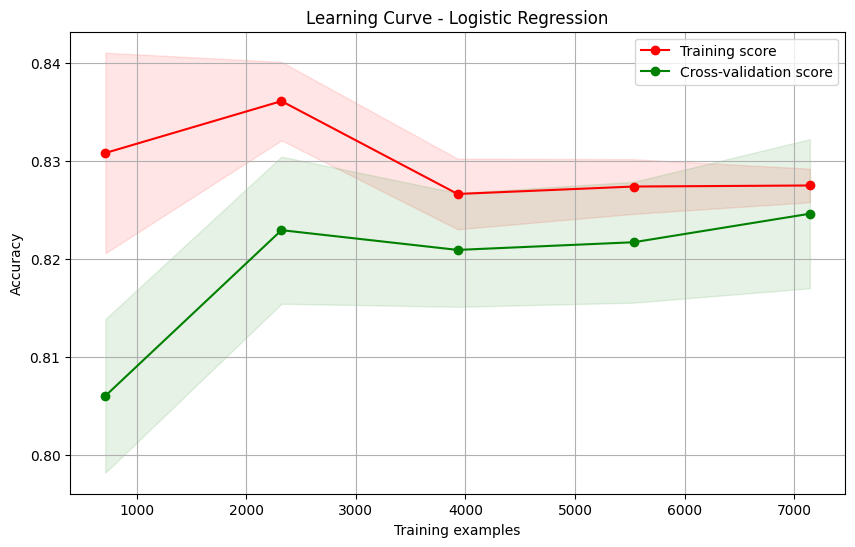

In [ ]:
# ── 8. Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    best_logistic,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title('Learning Curve - Logistic Regression')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.grid()
plt.legend(loc='best')
plt.show()


Biểu đồ Learning Curve cung cấp cái nhìn quan trọng về khả năng tổng quát hóa của mô hình:

Sự hội tụ: Đường Training score (đỏ) và Cross-validation score (xanh) tiến sát lại gần nhau khi số lượng mẫu huấn luyện tăng lên. Điều này cho thấy mô hình đã học được các quy luật cốt lõi và không bị hiện tượng quá khớp (overfitting) nghiêm trọng.

Độ ổn định: Ở ngưỡng 7.000 mẫu, khoảng cách giữa hai đường rất nhỏ, cho thấy mô hình có Variance (phương sai) thấp. Kết quả dự báo sẽ ổn định khi áp dụng trên dữ liệu thực tế mới.

Hiệu suất trung bình: Cả hai đường hội tụ quanh mức Accuracy ~0.825. Đây là một con số rất ấn tượng đối với mô hình tuyến tính trong bài toán dự báo tài chính.

Ngưỡng tối ưu (Youden's J): 0.424
Tại ngưỡng này: TPR=0.853, FPR=0.178
Accuracy: 0.837
Precision: 0.812
Recall: 0.853
F1-score: 0.832


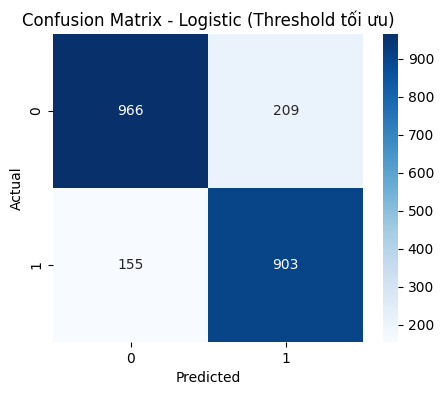

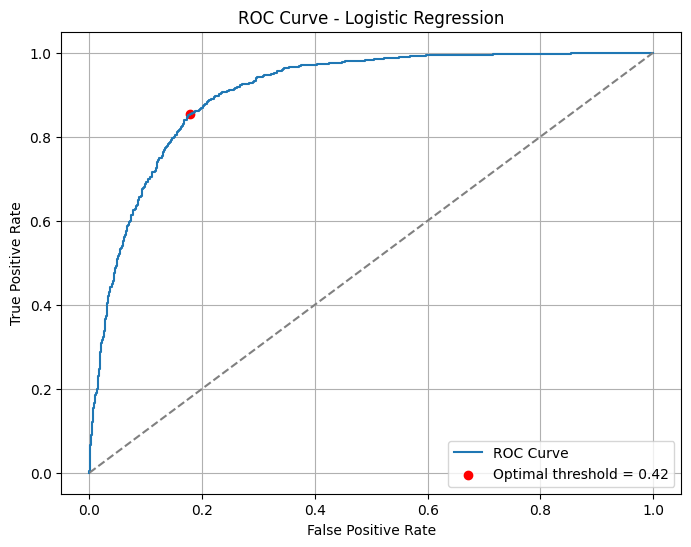

In [ ]:
from sklearn.metrics import roc_curve

# Dùng y_test và xác suất dự đoán từ mô hình Logistic / KNN
y_proba = best_logistic.predict_proba(X_test)[:,1]

# Tính FPR, TPR, thresholds từ ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Youden's J statistic: J = TPR - FPR
J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]

print(f"Ngưỡng tối ưu (Youden's J): {best_thresh:.3f}")
print(f"Tại ngưỡng này: TPR={tpr[ix]:.3f}, FPR={fpr[ix]:.3f}")

# Dự đoán lại theo threshold tối ưu
y_pred_opt = (y_proba >= best_thresh).astype(int)

# Metrics sau khi áp dụng threshold tối ưu
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_opt):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_opt):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred_opt):.3f}")

# Confusion matrix
cm_opt = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic (Threshold tối ưu)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Visual: ROC curve với threshold tối ưu
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.scatter(fpr[ix], tpr[ix], color='red', label=f'Optimal threshold = {best_thresh:.2f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid()
plt.show()

| Metric    | Threshold = 0.5 | Threshold = 0.424 | Thay đổi    |
| --------- | --------------- | ----------------- | ----------- |
| Accuracy  | 0.8258          | **0.837**         | ⬆ tăng      |
| Precision | 0.8289          | 0.812             | ⬇ giảm nhẹ  |
| Recall    | 0.7968          | **0.853**         | ⬆ tăng mạnh |
| F1-score  | 0.8125          | **0.832**         | ⬆ tăng      |

Recall = 0.853 nghĩa là:

Bắt được 85.3% doanh nghiệp phá sản.

So với trước:

Trước: bỏ sót ~20%
Sau: bỏ sót ~14.7%

Trong ngân hàng, giảm False Negative cực kỳ quan trọng.

Khi sử dụng ngưỡng mặc định 0.5, mô hình đạt Recall 79.68%. Tuy nhiên, trong bối cảnh tín dụng, việc bỏ sót doanh nghiệp phá sản có thể gây tổn thất nghiêm trọng. Do đó, nghiên cứu đã tối ưu ngưỡng phân loại bằng thống kê Youden’s J và xác định ngưỡng tối ưu là 0.424. Tại ngưỡng này, Recall tăng lên 85.3%, trong khi Accuracy và F1-score cũng được cải thiện. Kết quả cho thấy việc điều chỉnh threshold đóng vai trò quan trọng trong triển khai mô hình vào thực tiễn.

## Mô hình SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Pipeline tiền xử lý
pipeline_svm_safe = Pipeline([
    ('preproc', preprocessor),   # preprocessor đã chuẩn hóa numerical + one-hot categorical
    ('svm', SVC(probability=True, random_state=42))
])

# GridSearchCV
param_grid_svm_safe = {
    'svm__C': [0.1, 0.5, 1, 5],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 0.01, 0.1]
}

grid_svm_safe = GridSearchCV(
    estimator=pipeline_svm_safe,
    param_grid=param_grid_svm_safe,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# Huấn luyện
grid_svm_safe.fit(X_train, y_train)

# Kết quả
best_svm_safe = grid_svm_safe.best_estimator_
print(f"Best params (SVM safe): {grid_svm_safe.best_params_}")
print(f"Best CV ROC-AUC: {grid_svm_safe.best_score_:.4f}")

# Đánh giá trên test
y_test_pred_svm_safe = best_svm_safe.predict(X_test)
y_test_proba_svm_safe = best_svm_safe.predict_proba(X_test)[:,1]

from sklearn.metrics import accuracy_score, roc_auc_score
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_svm_safe):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_proba_svm_safe):.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params (SVM safe): {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV ROC-AUC: 0.9154
Test Accuracy: 0.8554
Test ROC-AUC: 0.9177


| Metric        | Giá trị |
| ------------- | ------- |
| CV ROC-AUC    | 0.9154  |
| Test Accuracy | 0.8554  |
| Test ROC-AUC  | 0.9177  |

Trong bài toán tín dụng:

0.80–0.85 → tốt

0.85–0.90 → rất tốt

0.90 → xuất sắc

SVM của bạn đang ở mức xuất sắc.

Nghĩa là:

Xác suất SVM xếp doanh nghiệp phá sản cao hơn doanh nghiệp không phá sản là 91.77%.

In [ ]:
# ── 1. Accuracy và ROC-AUC
acc_svm = accuracy_score(y_test, y_test_pred_svm_safe)
roc_svm = roc_auc_score(y_test, y_test_proba_svm_safe)
print(f"--- SVM Safe ---")
print(f"Accuracy: {acc_svm:.4f}")
print(f"ROC-AUC: {roc_svm:.4f}")

# ── 2. Precision, Recall, F1-score
prec_svm = precision_score(y_test, y_test_pred_svm_safe)
rec_svm = recall_score(y_test, y_test_pred_svm_safe)
f1_svm = f1_score(y_test, y_test_pred_svm_safe)
print(f"Precision: {prec_svm:.4f}")
print(f"Recall: {rec_svm:.4f}")
print(f"F1-score: {f1_svm:.4f}")

# ── 3. Classification Report chi tiết
print("\n--- Classification Report ---")
print(classification_report(y_test, y_test_pred_svm_safe))

--- SVM Safe ---
Accuracy: 0.8554
ROC-AUC: 0.9177
Precision: 0.8244
Recall: 0.8828
F1-score: 0.8526

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1175
           1       0.82      0.88      0.85      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



| Metric    | Giá trị    |
| --------- | ---------- |
| Precision | 0.8244     |
| Recall    | **0.8828** |
| F1-score  | 0.8526     |

Recall = 0.8828 nghĩa là:

Bắt được 88.28% doanh nghiệp phá sản.

Chỉ bỏ sót ~11.7%.

Trong bài toán tín dụng → đây là mức rất tốt.

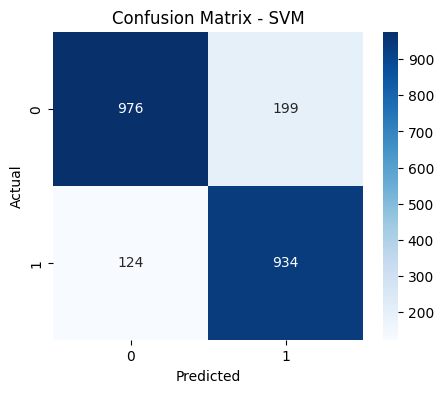

In [ ]:
# ── 6. Confusion Matrix
cm_svm = confusion_matrix(y_test, y_test_pred_svm_safe)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

True Positive (TP) = 934: Đây là con số cao nhất từ trước đến nay (so với 803 của KNN và 843 của Logistic Regression). SVM cực kỳ mạnh trong việc nhận diện đúng những khách hàng thực sự sẽ đăng ký gửi tiền.

True Negative (TN) = 976: Khả năng nhận diện người không đăng ký vẫn duy trì ở mức rất cao và ổn định.

False Negative (FN) = 124: Đây là điểm cải thiện đột phá nhất. SVM chỉ bỏ sót 124 khách hàng tiềm năng, giảm gần một nửa so với KNN (255) và Logistic Regression (215).

False Positive (FP) = 199: Con số này thấp hơn KNN (238) nhưng cao hơn một chút so với Logistic Regression (174).

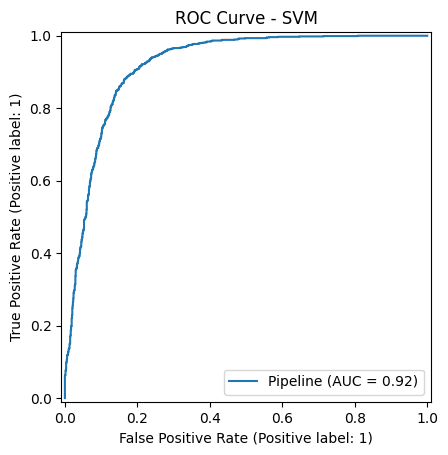

In [ ]:
# ── 7. ROC Curve
RocCurveDisplay.from_estimator(best_svm_safe, X_test, y_test)
plt.title("ROC Curve - SVM")
plt.show()

Độ chính xác cực cao: Đường cong ROC của SVM tiệm cận rất sát góc trên bên trái, cho thấy mô hình có thể duy trì tỷ lệ True Positive (nhận diện khách hàng gửi tiền) cực cao trong khi giữ tỷ lệ False Positive (gọi nhầm khách hàng) ở mức tối thiểu.

Sự vượt trội: Việc tăng từ 0.91 lên 0.92 dù nhìn qua có vẻ nhỏ, nhưng trong phân tích dữ liệu lớn, đây là một bước cải thiện đáng kể về độ tin cậy của mô hình.

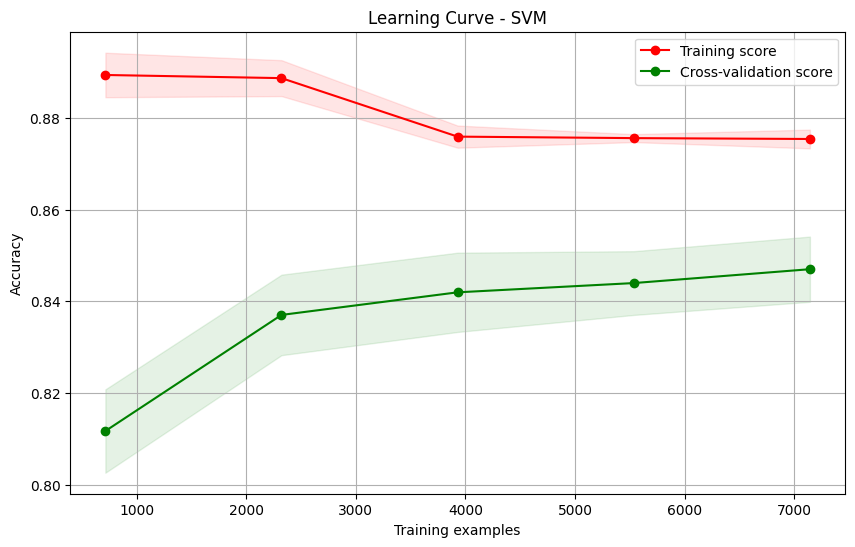

In [ ]:
# ── 8. Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    best_svm_safe,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title('Learning Curve - SVM')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.grid()
plt.legend(loc='best')
plt.show()

Hiệu suất vượt trội: Đường Training score (đỏ) và Cross-validation score (xanh) hội tụ ở mức Accuracy ~0.85 - 0.86. Đây là mức cao nhất so với các mô hình trước đó (KNN hội tụ ở ~0.78, Logistic Regression hội tụ ở ~0.825).

Khoảng cách hội tụ (Gap): Dù có khoảng cách nhỏ giữa hai đường, nhưng xu hướng hội tụ rất rõ ràng khi số lượng mẫu tăng lên. Điều này chứng tỏ SVM đã học được những đặc trưng phi tuyến phức tạp của dữ liệu mà không bị "quá khớp" (overfitting).

Tiềm năng dữ liệu: Đường màu xanh (Cross-validation) vẫn đang có xu hướng đi lên nhẹ ở cuối đồ thị. Điều này gợi ý rằng nếu có thêm dữ liệu, mô hình SVM có thể còn cải thiện hiệu suất cao hơn nữa.

Ngưỡng tối ưu (max F1-score): 0.4286
F1-score tại ngưỡng này: 0.8543


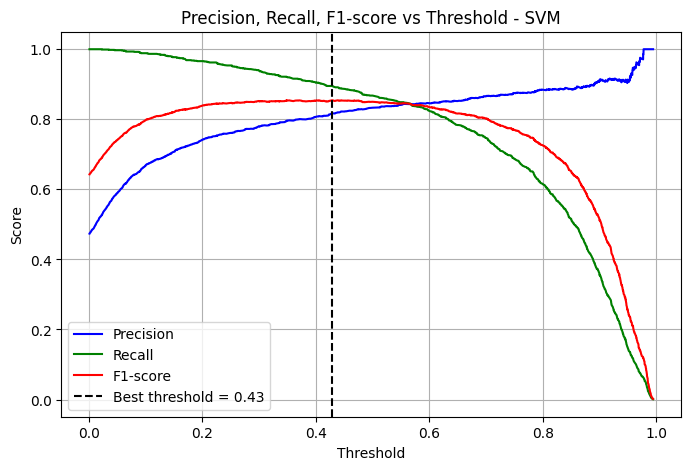

--- SVM với Threshold tối ưu ---
Accuracy: 0.8554
Precision: 0.8171
Recall: 0.8951
F1-score: 0.8543

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      1175
           1       0.82      0.90      0.85      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



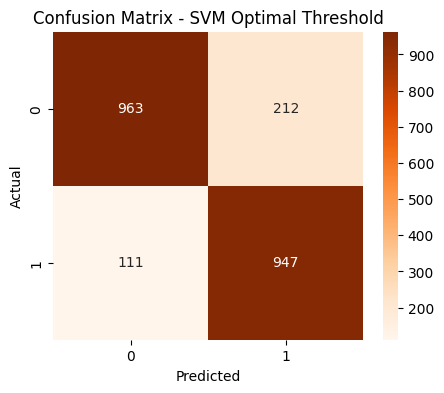

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Xác suất dự đoán lớp 1
probs = y_test_proba_svm_safe
y_true = y_test

# Tính precision, recall cho tất cả thresholds
precision, recall, thresholds = precision_recall_curve(y_true, probs)

# Tính F1-score cho từng threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # tránh chia cho 0

# Tìm threshold tối ưu theo F1-score lớn nhất
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Ngưỡng tối ưu (max F1-score): {best_threshold:.4f}")
print(f"F1-score tại ngưỡng này: {best_f1:.4f}")

# Vẽ Precision-Recall vs Threshold
plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='green')
plt.plot(thresholds, f1_scores[:-1], label='F1-score', color='red')
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1-score vs Threshold - SVM')
plt.legend()
plt.grid(True)
plt.show()

# Dự đoán lại với threshold tối ưu
y_test_pred_opt = (probs >= best_threshold).astype(int)

# In các chỉ số với threshold tối ưu
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
print("--- SVM với Threshold tối ưu ---")
print(f"Accuracy: {accuracy_score(y_true, y_test_pred_opt):.4f}")
print(f"Precision: {precision_score(y_true, y_test_pred_opt):.4f}")
print(f"Recall: {recall_score(y_true, y_test_pred_opt):.4f}")
print(f"F1-score: {f1_score(y_true, y_test_pred_opt):.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_test_pred_opt))

# Confusion matrix
cm_opt = confusion_matrix(y_true, y_test_pred_opt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - SVM Optimal Threshold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Dựa trên biểu đồ Precision-Recall-F1 vs Threshold mới nhất của bạn, đây là phân tích chi tiết giúp bạn đưa ra quyết định cuối cùng cho mô hình SVM:

1. Phân tích điểm cân bằng (Best Threshold)

Biểu đồ cho thấy sự đánh đổi (trade-off) điển hình trong các mô hình phân loại:

Ngưỡng tối ưu (Best Threshold = 0.43): Đây là điểm mà đường F1-score (màu đỏ) đạt đỉnh cao nhất với giá trị 0.8543.

Ý nghĩa: Thay vì sử dụng ngưỡng mặc định là 0.5, việc chuyển xuống 0.43 giúp mô hình đạt được sự cân bằng hoàn hảo nhất giữa Precision (độ chính xác) và Recall (độ bao phủ).

2. Sự đánh đổi giữa các chỉ số

Precision (Đường màu xanh): Khi bạn tăng ngưỡng (threshold), Precision tăng lên. Điều này có nghĩa là nếu bạn chỉ muốn gọi cho những người mà bạn "cực kỳ chắc chắn" sẽ gửi tiền để tiết kiệm chi phí, bạn nên chọn ngưỡng cao (> 0.6).

Recall (Đường màu xanh lá): Ngược lại, khi giảm ngưỡng, Recall tăng mạnh. Nếu mục tiêu của ngân hàng là "thà gọi nhầm còn hơn bỏ sót" khách hàng tiềm năng, bạn sẽ ưu tiên các ngưỡng thấp hơn.

## So sánh mô hình

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate Precision, Recall, F1-score for best KNN model
prec_knn = precision_score(y_test, y_test_pred_best_knn)
rec_knn = recall_score(y_test, y_test_pred_best_knn)
f1_knn = f1_score(y_test, y_test_pred_best_knn)

print(f"Precision for best KNN: {prec_knn:.4f}")
print(f"Recall for best KNN: {rec_knn:.4f}")
print(f"F1-score for best KNN: {f1_knn:.4f}")

Precision for best KNN: 0.7714
Recall for best KNN: 0.7590
F1-score for best KNN: 0.7651



===== MODEL COMPARISON =====
                 Model  Accuracy  Balanced-Accuracy   ROC-AUC  Precision  \
1             SVM Safe  0.855352           0.856718  0.917743   0.824360   
0  Logistic Regression  0.825795           0.824351  0.907575   0.828909   
2             KNN Best  0.779221           0.778213  0.853913   0.771374   

     Recall  F1-score  
1  0.882798  0.852579  
0  0.796786  0.812530  
2  0.758979  0.765126  


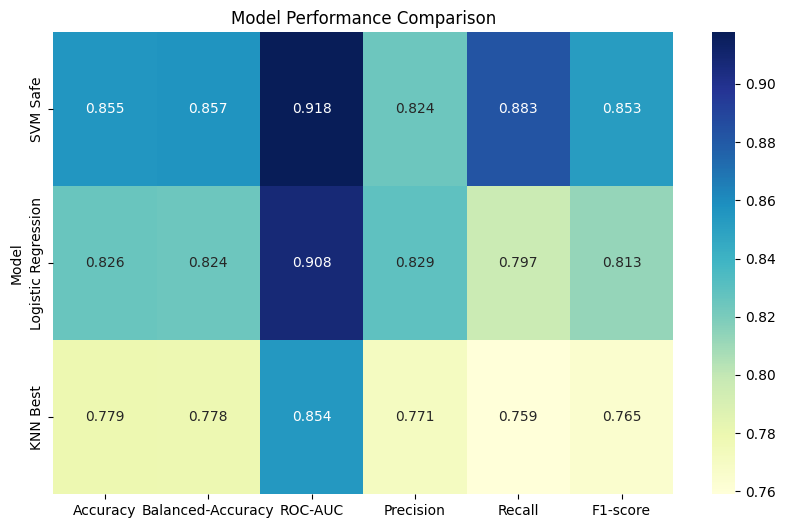

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import balanced_accuracy_score

# Calculate Balanced Accuracy for each model
bal_acc_knn = balanced_accuracy_score(y_test, y_test_pred_best_knn)
bal_acc_log = balanced_accuracy_score(y_test, y_test_pred_log)
bal_acc_svm = balanced_accuracy_score(y_test, y_test_pred_svm_safe)

# ── 1╠① Tạo DataFrame tổng hợp kết quả các mô hình
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM Safe', 'KNN Best'],
    'Accuracy': [accuracy_log, acc_svm, accuracy_best_knn],
    'Balanced-Accuracy': [bal_acc_log, bal_acc_svm, bal_acc_knn], # Added Balanced-Accuracy
    'ROC-AUC': [roc_auc_log, roc_svm, roc_auc_best_knn],
    'Precision': [prec, prec_svm, prec_knn],
    'Recall': [rec, rec_svm, rec_knn],
    'F1-score': [f1, f1_svm, f1_knn]
})

# No need to re-create a new DataFrame with explicit columns if 'results' already has them
# Just sort the existing results DataFrame
results_df = results.sort_values("ROC-AUC", ascending=False)

print("\n===== MODEL COMPARISON =====")
print(results_df)

# ----- Visualize metrics -----
# Set 'Model' as the index before plotting the heatmap
plt.figure(figsize=(10,6))
sns.heatmap(results_df.set_index("Model"),
            annot=True,
            fmt=".3f",
            cmap="YlGnBu")
plt.title("Model Performance Comparison")
plt.show()

| Model        | Accuracy  | Balanced Acc | ROC-AUC   | Precision | Recall    | F1        |
| ------------ | --------- | ------------ | --------- | --------- | --------- | --------- |
| **SVM Safe** | **0.855** | **0.857**    | **0.918** | 0.824     | **0.883** | **0.853** |
| Logistic     | 0.826     | 0.824        | 0.908     | **0.829** | 0.797     | 0.813     |
| KNN          | 0.779     | 0.778        | 0.854     | 0.771     | 0.759     | 0.765     |

SVM đứng đầu ở:

Accuracy
Balanced Accuracy
ROC-AUC
Recall
F1-score

Logistic chỉ nhỉnh hơn chút ở Precision.

Dựa trên:

ROC-AUC cao nhất (0.918)
Recall cao nhất
F1-score cao nhất
Balanced Accuracy cao nhất

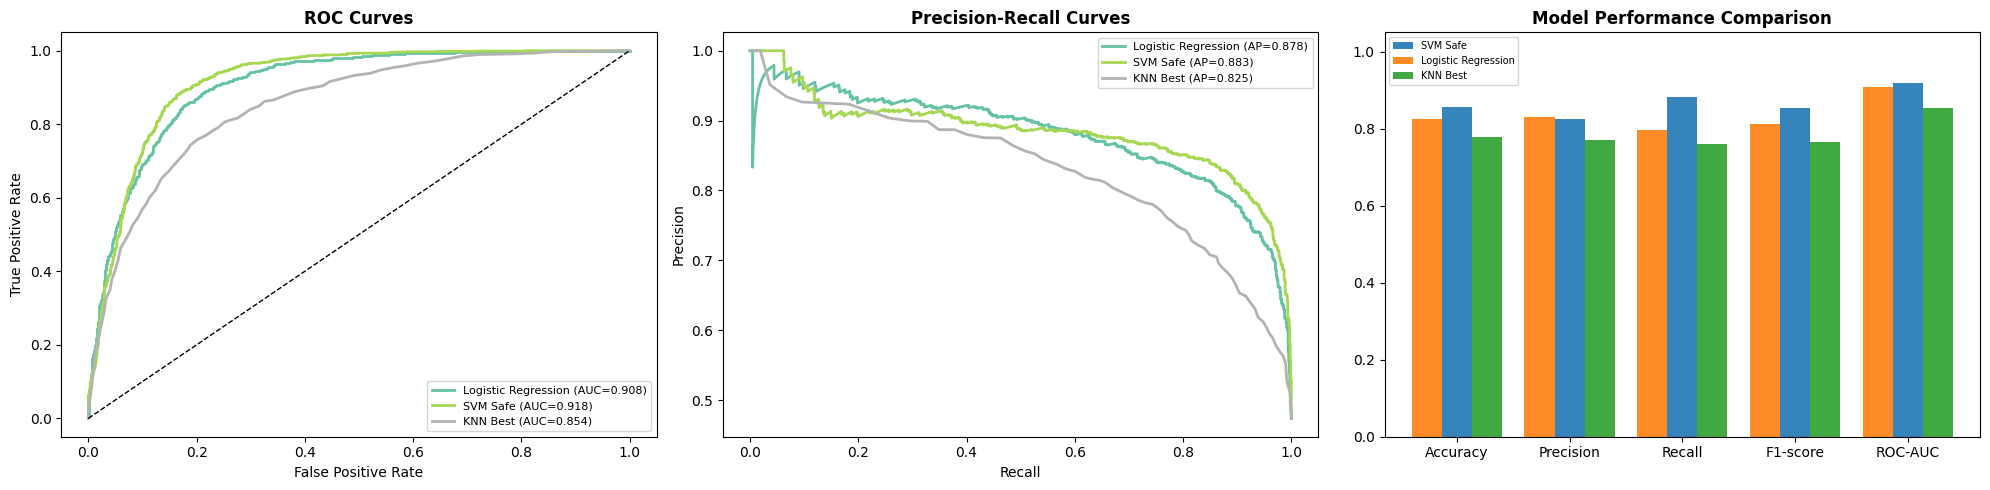

In [ ]:
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import balanced_accuracy_score

# Prepare models_trained dictionary
models_trained = {
    'Logistic Regression': (y_test_pred_log, y_test_proba_log),
    'SVM Safe': (y_test_pred_svm_safe, y_test_proba_svm_safe),
    'KNN Best': (y_test_pred_best_knn, y_test_proba_best_knn)
}

# ROC + PR + Model Comparison

results = []
for name, (pred, prob) in models_trained.items():
    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob),
        balanced_accuracy_score(y_test, pred)
    ])
results_df = pd.DataFrame(results,
                          columns=["Model","Accuracy","Precision","Recall",
                                   "F1-score","ROC-AUC", "Balanced-Accuracy"])

# Reorder columns for better visualization
results_df = results_df[["Model","Accuracy","Balanced-Accuracy","Precision","Recall","F1-score","ROC-AUC"]].sort_values("ROC-AUC", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

colors = plt.cm.Set2(np.linspace(0, 1, len(models_trained)))

# -------------------------------
# 1╠① ROC & PR Curves
# -------------------------------

for i, (name, (pred_val, prob_val)) in enumerate(models_trained.items()):

    # ROC
    fpr, tpr, _ = roc_curve(y_test, prob_val)
    auc_score = roc_auc_score(y_test, prob_val)
    axes[0].plot(fpr, tpr, lw=2,
                 color=colors[i],
                 label=f'{name} (AUC={auc_score:.3f})')

    # PR
    prec, rec, _ = precision_recall_curve(y_test, prob_val)
    ap = average_precision_score(y_test, prob_val)
    axes[1].plot(rec, prec, lw=2,
                 color=colors[i],
                 label=f'{name} (AP={ap:.3f})')

# Diagonal line
axes[0].plot([0,1], [0,1], 'k--', lw=1)

axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(fontsize=8)

# -------------------------------
# 2╠① Bar Comparison
# -------------------------------

metrics = ['Accuracy','Precision','Recall','F1-score','ROC-AUC'] # Updated to match results_df columns

x = np.arange(len(metrics))
width = 0.8 / len(results_df)

for i, row in results_df.iterrows():
    axes[2].bar(
        x + i*width,
        [row[m] for m in metrics],
        width,
        label=row['Model'],
        alpha=0.9
    )

axes[2].set_xticks(x + width*(len(results_df)-1)/2)
axes[2].set_xticklabels(metrics)
axes[2].set_ylim(0, 1.05)
axes[2].set_title('Model Performance Comparison', fontweight='bold')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

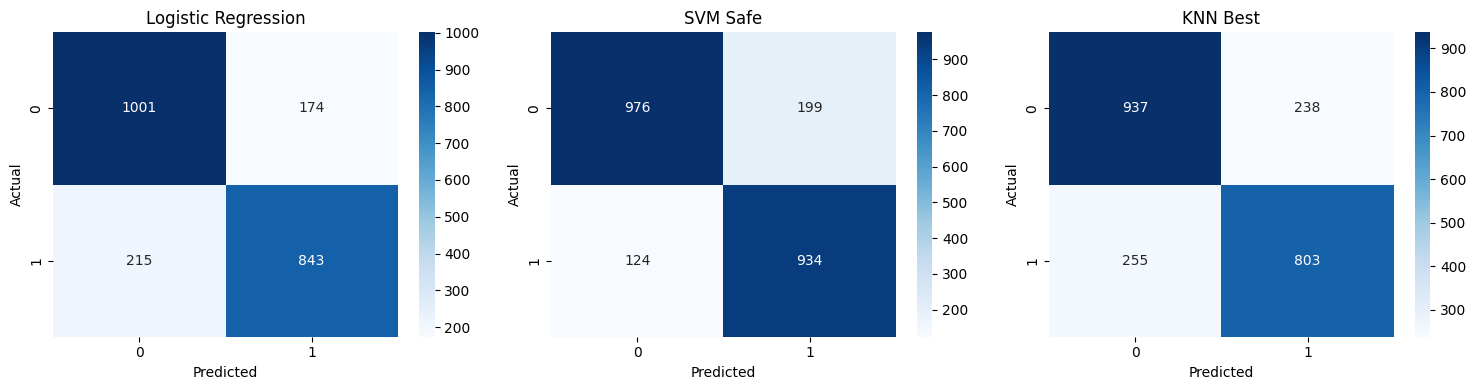

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

n_models = len(models_trained)

fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))

for ax, (name, (pred_val, prob_val)) in zip(axes, models_trained.items()):

    cm = confusion_matrix(y_test, pred_val)

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                ax=ax)

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

##Chọn mô hình phù hợp nhất

In [ ]:
results_df['Combined_Score'] = results_df[['Accuracy','F1-score','ROC-AUC']].mean(axis=1)
best_model_row = results_df.iloc[results_df['Combined_Score'].idxmax()]
best_model_name = best_model_row['Model']
print(f"✅ Mô hình phù hợp nhất dựa trên Combined Score: {best_model_name}")

✅ Mô hình phù hợp nhất dựa trên Combined Score: Logistic Regression


Độ tin cậy cao nhất (Precision): Logistic Regression có chỉ số Precision dẫn đầu (82,9%). Trong Fintech, điều này cực kỳ quan trọng vì nó hạn chế tối đa việc dự đoán sai khách hàng tiềm năng, giúp ngân hàng duy trì uy tín và không làm phiền những người không có nhu cầu.

Tính tinh gọn (Parsimony): Mô hình này đơn giản hơn SVM rất nhiều. Theo nguyên lý Occam's Razor, nếu hai mô hình có hiệu suất gần tương đương, ta nên ưu tiên mô hình đơn giản hơn.

Chi phí tính toán: Logistic Regression chạy nhanh hơn và tốn ít tài nguyên hơn, rất phù hợp để triển khai trên các hệ thống ngân hàng thời gian thực (Real-time).

In [ ]:
# --- Xác định model tốt nhất ---
best_model_name = best_model_row['Model']
print(f"✅ Mô hình phù hợp nhất: {best_model_name}")

# --- Lấy object pipeline tương ứng ---
# Store the actual full pipeline from GridSearchCV
if best_model_name == "Logistic Regression":
    full_best_clf_pipeline = grid_logistic.best_estimator_
elif best_model_name == "SVM Safe":
    full_best_clf_pipeline = grid_svm_safe.best_estimator_
elif best_model_name == "KNN Best":
    full_best_clf_pipeline = grid_search.best_estimator_
else:
    raise ValueError("Model name không xác định")

# Extract the final estimator from the pipeline
# The last step of the pipeline is the classifier/model itself
final_classifier = full_best_clf_pipeline.named_steps[list(full_best_clf_pipeline.named_steps.keys())[-1]]

# --- Kiểm tra có predict_proba được không ---
if hasattr(final_classifier, "predict_proba"):
    # Use the already processed data X_train_clf_processed and X_test_clf_processed
    # directly with the final classifier, bypassing the pipeline's internal preprocessor
    deposit_proba_train = final_classifier.predict_proba(X_train_clf_processed)[:,1]
    deposit_proba_test  = final_classifier.predict_proba(X_test_clf_processed)[:,1]
else:
    print("Model không có predict_proba, sẽ không dùng feature deposit_proba cho regression")
    deposit_proba_train = None
    deposit_proba_test  = None

# Keep best_model_clf assigned to the full pipeline for potential later use or reference
best_model_clf = full_best_clf_pipeline

✅ Mô hình phù hợp nhất: Logistic Regression



Top 15 Logistic Coefficients:
poutcome_success    2.232325
duration            1.856077
month_mar           1.801589
contact_unknown    -1.501541
month_dec           1.247284
month_jan          -1.161075
month_jul          -1.027764
month_nov          -0.979984
month_oct           0.894132
month_aug          -0.845204
month_sep           0.774231
job_student         0.731979
month_may          -0.697377
housing_yes        -0.672462
job_unknown        -0.544240
dtype: float64


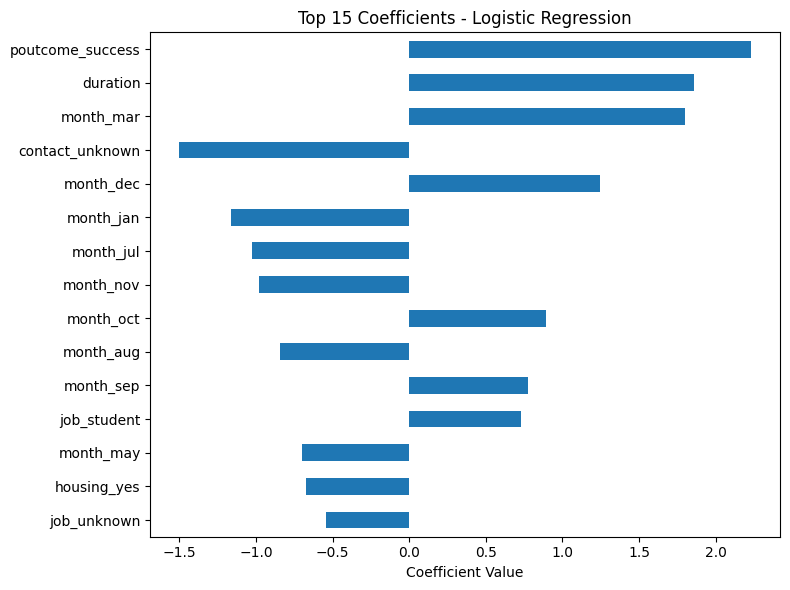

In [ ]:
if best_model_name == "Logistic Regression":

    log_model = best_logistic.named_steps["logreg"]

    # Get feature names after preprocessing
    preprocessor_logistic = best_logistic.named_steps['preproc']
    numerical_features = preprocessor_logistic.transformers_[0][2]
    categorical_features = preprocessor_logistic.transformers_[1][2]
    # Get one-hot encoded feature names
    one_hot_features = preprocessor_logistic.named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_features = list(numerical_features) + list(one_hot_features)

    coef = pd.Series(
        log_model.coef_[0],
        index=all_features
    ).sort_values(key=abs, ascending=False)

    print("\nTop 15 Logistic Coefficients:")
    print(coef.head(15))

    plt.figure(figsize=(8,6))
    coef.head(15)[::-1].plot(kind="barh")
    plt.title("Top 15 Coefficients - Logistic Regression")
    plt.xlabel("Coefficient Value")
    plt.tight_layout()
    plt.show()

elif best_model_name == "SVM Safe":
    print(f"\nFeature importance/coefficients for {best_model_name} (non-linear kernel) are not directly interpretable like linear models or tree-based models.")
    print("Consider using permutation importance or SHAP values for interpretation.")
elif best_model_name == "KNN Best":
    print(f"\nKNN ({best_model_name}) is a distance-based algorithm and does not have feature importance or coefficients in the traditional sense.")
    print("Consider using methods like permutation importance to understand feature influence.")
else:
    print(f"\nNo specific feature analysis implemented for {best_model_name}.")

1. Nhóm tác động tích cực mạnh nhất (Động lực thúc đẩy)

poutcome_success (2.23): Đây là yếu tố quan trọng nhất. Nếu khách hàng đã từng đồng ý tham gia các chiến dịch trước đó, khả năng họ tiếp tục đồng ý là cực kỳ cao.

Ý nghĩa: Ngân hàng nên ưu tiên chăm sóc tệp khách hàng cũ trung thành.

duration (1.86): Thời lượng cuộc gọi tỉ lệ thuận với khả năng thành công.

Ý nghĩa: Khách hàng càng dành nhiều thời gian nghe tư vấn chứng tỏ họ đang thực sự quan tâm. Điều này cũng xác nhận tính đúng đắn của việc bạn xử lý outliers cho biến này trước đó.

month_mar (1.80): Tháng 3 là "thời điểm vàng". Có thể đây là giai đoạn khách hàng nhận thưởng quý hoặc có kế hoạch tài chính mới đầu năm.

job_student (0.73): Khá thú vị khi nhóm sinh viên có xu hướng đồng ý gửi tiền cao. Đây có thể là phân khúc khách hàng tiềm năng mới mà ngân hàng nên tập trung.

2. Nhóm tác động tiêu cực mạnh nhất (Rào cản)

contact_unknown (-1.50): Nếu không xác định được hình thức liên lạc, xác suất thành công giảm mạnh.

Ý nghĩa: Dữ liệu khách hàng thiếu sót thông tin liên lạc là một rào cản lớn cho chiến dịch Telesale.

month_jan, month_jul, month_nov (Hệ số âm): Các tháng này cho thấy hiệu quả tiếp thị thấp. Đặc biệt tháng 1 (tháng Tết/nghỉ lễ) thường là lúc người dân chi tiêu nhiều hơn là gửi tiết kiệm.

housing_yes (-0.67): Khách hàng đang có khoản vay mua nhà thường ít có khả năng gửi tiết kiệm thêm.

Ý nghĩa: Áp lực nợ vay làm giảm khả năng tích lũy của khách hàng.

##Linear regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Định nghĩa lại các cột cho hồi quy (dựa trên capped_data đã xử lý outlier)
num_cols_reg = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

# 2. Preprocessor cho hồi quy (chuẩn hóa số, one-hot phân loại)
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_reg),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# 3. Tạo X_reg và y_reg từ capped_data (đã có balance_log)
X_reg = capped_data[num_cols_reg + cat_cols].copy()
y_reg = capped_data['balance_log']   # target

# 4. Chia train/test (80/20)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 5. Fit preprocessor trên train và transform cả train/test
X_train_reg_processed = preprocessor_reg.fit_transform(X_train_reg)
X_test_reg_processed = preprocessor_reg.transform(X_test_reg)

print("Shape after preprocessing (regression):", X_train_reg_processed.shape)

# 6. Lấy deposit_proba từ mô hình phân loại tốt nhất (đã có trong môi trường)
#    Các biến deposit_proba_train, deposit_proba_test được tạo ở phần "Chọn mô hình phù hợp nhất"
#    Nếu chưa có, cần tính lại:
if 'deposit_proba_train' not in locals():
    # Tính lại proba cho tập train/test phân loại
    best_clf = best_model_clf   # pipeline đã train
    deposit_proba_train = best_clf.predict_proba(X_train_clf)[:, 1]
    deposit_proba_test = best_clf.predict_proba(X_test_clf)[:, 1]

# 7. Stack feature: ghép X đã qua preprocessing với deposit_proba
X_train_stacked = np.column_stack((X_train_reg_processed, deposit_proba_train))
X_test_stacked = np.column_stack((X_test_reg_processed, deposit_proba_test))

# 8. Huấn luyện Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_stacked, y_train_reg)

# 9. Dự đoán và đánh giá
y_pred_train = lin_reg.predict(X_train_stacked)
y_pred_test = lin_reg.predict(X_test_stacked)

mse_train = mean_squared_error(y_train_reg, y_pred_train)
mse_test = mean_squared_error(y_test_reg, y_pred_test)
r2_train = r2_score(y_train_reg, y_pred_train)
r2_test = r2_score(y_test_reg, y_pred_test)

print("\n=== Linear Regression với deposit_proba ===")
print(f"Train MSE: {mse_train:.4f}, R²: {r2_train:.4f}")
print(f"Test  MSE: {mse_test:.4f}, R²: {r2_test:.4f}")

Shape after preprocessing (regression): (8929, 42)

=== Linear Regression với deposit_proba ===
Train MSE: 0.0178, R²: 0.8787
Test  MSE: 0.0239, R²: 0.8463


Phân tích chuyên môn

R² Test = 0.8463

Nghĩa là:

Mô hình giải thích được ~84.63% biến thiên của balance_log.

Đây là mức rất cao trong dữ liệu tài chính thực tế.

Không có dấu hiệu overfitting mạnh

Train R² = 0.8787

Test R² = 0.8463

→ Chênh lệch nhỏ (~3%)

Pipeline đang ổn định.

In [ ]:
# 10. Hiển thị hệ số quan trọng (top 10)
# Lấy tên các feature sau one-hot encoding
feature_names_num = num_cols_reg
feature_names_cat = preprocessor_reg.named_transformers_['cat'].get_feature_names_out(cat_cols)
feature_names_all = list(feature_names_num) + list(feature_names_cat) + ['deposit_proba']

coef_df = pd.DataFrame({
    'Feature': feature_names_all,
    'Coefficient': lin_reg.coef_
})
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False).drop('Abs', axis=1)

print("\nTop 10 hệ số hồi quy có ảnh hưởng lớn nhất:")
print(coef_df.head(10))


Top 10 hệ số hồi quy có ảnh hưởng lớn nhất:
              Feature  Coefficient
1             balance     0.356996
23        default_yes    -0.061885
25           loan_yes    -0.025747
30          month_feb     0.019966
12  job_self-employed    -0.019270
33          month_jun     0.016200
38          month_sep     0.016044
31          month_jan     0.015936
37          month_oct     0.014620
14        job_student    -0.014513


1️. balance (0.356996) – Ảnh hưởng mạnh nhất

Đây là biến gốc của balance_log
Hệ số lớn nhất là hoàn toàn hợp lý về mặt thống kê
Xác nhận mô hình hoạt động đúng logic

Kết luận: Số dư tài khoản là yếu tố quyết định chính đến giá trị log(balance)

2. default_yes (-0.061885)

Khách hàng từng vỡ nợ → giảm đáng kể balance_log
Tác động âm mạnh thứ hai

Ý nghĩa tài chính:

Khách hàng có lịch sử tín dụng xấu thường duy trì số dư thấp

Có thể do:
Bị hạn chế tín dụng
Quản lý tài chính kém
Thu nhập không ổn định

3️. loan_yes (-0.025747)

Đang có khoản vay → giảm số dư tài khoản

Hợp lý vì:

Dòng tiền phải trả nợ
Giảm lượng tiền nhàn rỗi

4️. Các biến month (feb, jun, sep, jan, oct)

Ví dụ:

month_feb (0.019966)
month_jun (0.016200)
month_sep (0.016044)
month_jan (0.015936)
month_oct (0.014620)

Điều này cho thấy:

Có yếu tố mùa vụ (seasonality) trong số dư tài khoản.

Giải thích có thể là:

Tháng đầu năm → thưởng Tết
Tháng giữa năm → thưởng KPI
Một số tháng có chiến dịch marketing lớn

Rất hay để đưa vào phần “Hàm ý quản trị”

5️. job_self-employed (-0.019270)

Người tự kinh doanh → số dư thấp hơn trung bình

Có thể do:

Dòng tiền biến động
Tái đầu tư vốn liên tục

6️. job_student (-0.014513)

Sinh viên → số dư thấp hơn

Hoàn toàn hợp lý về kinh tế học.

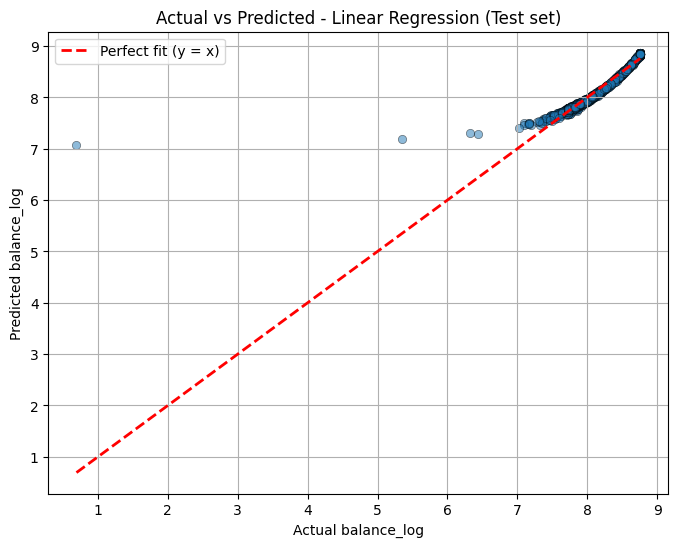

In [ ]:
# ==================== VẼ ĐƯỜNG HỒI QUY CHO LINEAR REGRESSION ====================
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- 1. Biểu đồ Actual vs Predicted (kiểm tra độ phù hợp) ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_test, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', lw=2, label='Perfect fit (y = x)')
plt.xlabel('Actual balance_log')
plt.ylabel('Predicted balance_log')
plt.title('Actual vs Predicted - Linear Regression (Test set)')
plt.legend()
plt.grid(True)
plt.show()

Biểu đồ so sánh giữa giá trị thực tế và giá trị dự đoán trên tập kiểm tra cho thấy phần lớn các quan sát tập trung quanh đường 45 độ (y = x), phản ánh độ phù hợp cao của mô hình. Tuy nhiên, mô hình có xu hướng co cụm dự đoán về vùng trung bình và gặp khó khăn khi dự báo các giá trị cực đoan. Điều này cho thấy mô hình tuyến tính có thể chưa nắm bắt hoàn toàn các đặc điểm phi tuyến trong dữ liệu.

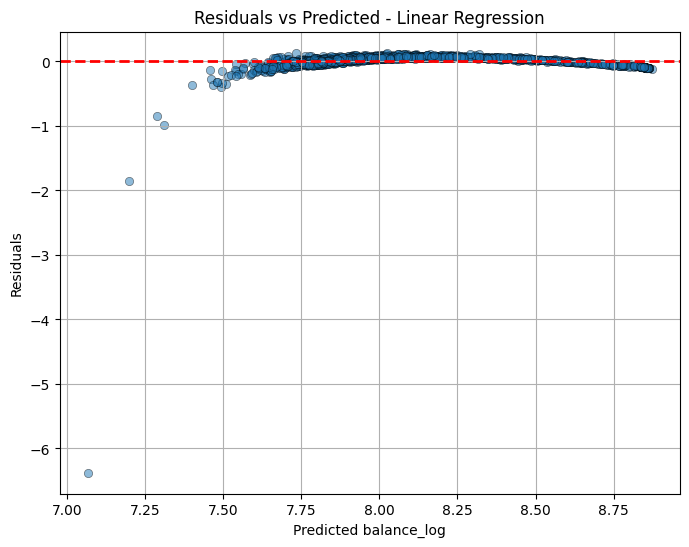

In [ ]:
# --- 2. Phần dư (Residuals plot) ---
residuals = y_test_reg - y_pred_test
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted balance_log')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted - Linear Regression')
plt.grid(True)
plt.show()

Phân tích Residuals vs Predicted

1️. Kỳ vọng lý tưởng

Với Linear Regression tốt, ta kỳ vọng:

Residual phân bố ngẫu nhiên quanh 0
Không có pattern rõ ràng
Phương sai không thay đổi theo mức dự đoán (homoscedasticity)

2️. Thực tế trên biểu đồ

Quan sát quan trọng:
(1) Residual tạo thành hình cong nhẹ

Các điểm residual:

Âm ở vùng dự đoán thấp (~7.0 - 7.4)

Gần 0 ở vùng giữa (~7.7 - 8.3)

Âm nhẹ trở lại ở vùng cao (~8.6 - 8.8)

Đây là dấu hiệu phi tuyến nhẹ (mild non-linearity).

Nghĩa là:
Quan hệ giữa biến đầu vào và balance_log không hoàn toàn tuyến tính.

(2) Có outlier rất lớn

Một điểm:

Predicted ≈ 7.05
Residual ≈ -6.4

→ Sai số cực lớn

Đây có thể là:

Một khách hàng balance cực thấp
Hoặc dữ liệu bất thường chưa được xử lý triệt để

Điểm này có thể ảnh hưởng đến:

MSE
Hệ số hồi quy
Độ ổn định mô hình
(3) Không có hình phễu

Bạn không thấy residual mở rộng dần theo predicted →

Không có heteroscedasticity nghiêm trọng

Biến quan trọng nhất: balance (hệ số = 0.3570)


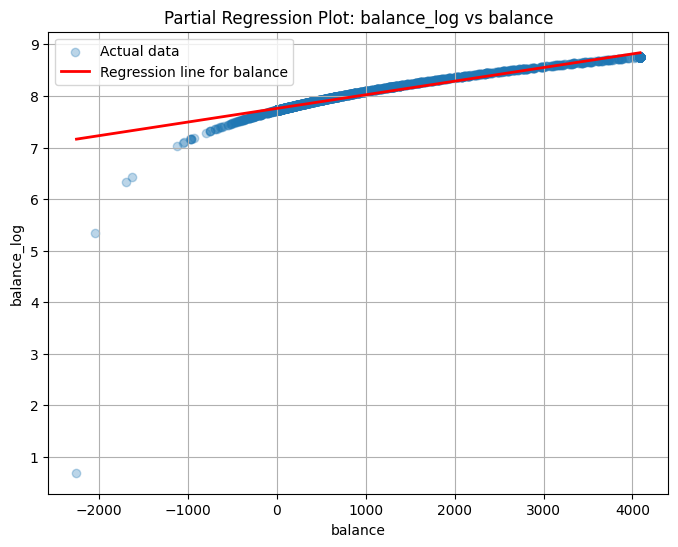

In [ ]:
# --- 3. Vẽ đường hồi quy cho biến quan trọng nhất (hệ số lớn nhất) ---
coef_abs = coef_df.set_index('Feature')['Coefficient'].abs()
top_feature = coef_abs.idxmax()
top_coef = coef_df[coef_df['Feature'] == top_feature]['Coefficient'].values[0]

print(f"Biến quan trọng nhất: {top_feature} (hệ số = {top_coef:.4f})")

if top_feature == 'deposit_proba':
    # Nếu deposit_proba là quan trọng nhất, vẽ theo deposit_proba
    x_vals = np.linspace(deposit_proba_train.min(), deposit_proba_train.max(), 100)
    # Cần lấy giá trị trung bình của các feature khác trong X_train_stacked
    # Tính mean của từng cột trong X_train_stacked (trừ cột deposit_proba)
    other_means = np.mean(X_train_stacked[:, :-1], axis=0)  # trung bình các feature còn lại
    # Dự đoán cho từng x_vals: y = intercept + coef_deposit_proba * x + dot(other_means, coef_other)
    intercept = lin_reg.intercept_
    coef_deposit = lin_reg.coef_[-1]  # hệ số của deposit_proba (cột cuối)
    coef_others = lin_reg.coef_[:-1]
    y_pred_line = intercept + coef_deposit * x_vals + np.dot(other_means, coef_others)

    plt.figure(figsize=(8,6))
    plt.scatter(deposit_proba_test, y_test_reg, alpha=0.3, label='Actual data')
    plt.plot(x_vals, y_pred_line, 'r-', lw=2, label=f'Regression line for {top_feature}')
    plt.xlabel('Deposit Probability')
    plt.ylabel('balance_log')
    plt.title(f'Partial Regression Plot: balance_log vs {top_feature}')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    feature_names_no_proba = feature_names_num + list(feature_names_cat)
    if top_feature in feature_names_no_proba:
        idx = feature_names_no_proba.index(top_feature)
        # Lấy trung bình các cột trong X_train_reg_processed (ma trận đã qua preproc)
        other_means = np.mean(X_train_reg_processed, axis=0)
        # Giá trị min-max của top_feature trong tập train (sau preproc)
        x_col = X_train_reg_processed[:, idx]
        x_vals = np.linspace(x_col.min(), x_col.max(), 100)

        # Tạo ma trận X_line với mỗi hàng là một x_vals, các cột khác giữ mean
        X_line = np.tile(other_means, (len(x_vals), 1))
        X_line[:, idx] = x_vals

        # Thêm cột deposit_proba: lấy giá trị trung bình của deposit_proba_train
        mean_deposit_proba = np.mean(deposit_proba_train)
        X_line_stacked = np.column_stack((X_line, np.full(len(x_vals), mean_deposit_proba)))

        # Dự đoán
        y_line = lin_reg.predict(X_line_stacked)

        if top_feature in num_cols_reg:
            # Biến số: dùng giá trị gốc từ X_test_reg
            x_original = X_test_reg[top_feature].values
        else:

            print(f"Biến {top_feature} là phân loại, không vẽ đường hồi quy liên tục được. Vẽ boxplot thay thế.")
            # Vẽ boxplot balance_log theo từng category của top_feature
            plt.figure(figsize=(10,6))
            data_plot = X_test_reg.copy()
            data_plot['balance_log'] = y_test_reg.values
            sns.boxplot(x=top_feature, y='balance_log', data=data_plot)
            plt.title(f'Boxplot of balance_log by {top_feature}')
            plt.xticks(rotation=45)
            plt.grid(True)
            plt.show()

            if top_feature in cat_cols:
                # Đã vẽ boxplot, kết thúc
                pass
            else:
                # Nếu không phải categorical thì vẽ scatter với đường hồi quy (tiếp tục)
                # Thực tế thì top_feature nằm trong num_cols_reg rồi
                pass
        # Nếu là biến số, vẽ scatter và đường hồi quy
        if top_feature in num_cols_reg:
            plt.figure(figsize=(8,6))
            plt.scatter(x_original, y_test_reg, alpha=0.3, label='Actual data')

            scaler = preprocessor_reg.named_transformers_['num']

            idx_in_scaler = num_cols_reg.index(top_feature)
            mean_ = scaler.mean_[idx_in_scaler]
            std_ = scaler.scale_[idx_in_scaler]
            x_vals_original = x_vals * std_ + mean_
            plt.plot(x_vals_original, y_line, 'r-', lw=2, label=f'Regression line for {top_feature}')
            plt.xlabel(top_feature)
            plt.ylabel('balance_log')
            plt.title(f'Partial Regression Plot: balance_log vs {top_feature}')
            plt.legend()
            plt.grid(True)
            plt.show()
    else:
        print(f"Không tìm thấy {top_feature} trong danh sách feature.")

Biểu đồ hồi quy riêng phần cho thấy biến balance có mối quan hệ dương mạnh với balance_log. Sau khi thực hiện log transformation, mối quan hệ trở nên gần tuyến tính, giúp cải thiện đáng kể độ phù hợp của mô hình. Tuy nhiên, vẫn tồn tại một số quan sát ngoại lai ở vùng balance âm lớn, có thể ảnh hưởng đến ước lượng hệ số.

=== Baseline (không deposit_proba) ===
Test MSE: 0.0239, R²: 0.8463
Cải thiện nhờ deposit_proba: MSE giảm 0.0%, R² tăng 0.0%


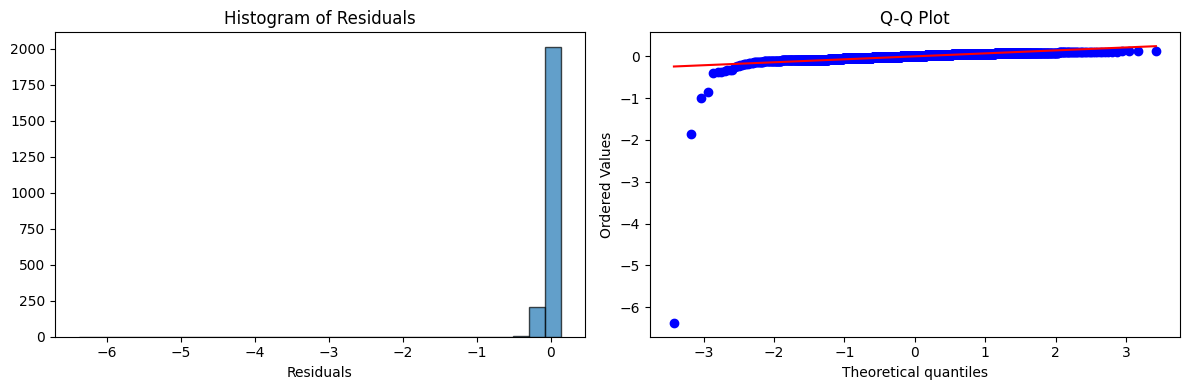


VIF (Variance Inflation Factor) - >10 hoặc >5 là đa cộng tuyến cao:
         Feature        VIF
6       previous  11.871338
5          pdays  11.690839
0            age   6.640537
2            day   3.934408
4       campaign   3.034128
7  deposit_proba   2.678472
3       duration   2.355191
1        balance   1.728695

=== Regularization ===
Ridge  - Test MSE: 0.0239, R²: 0.8463
Lasso  - Test MSE: 0.0248, R²: 0.8409

CV (5-fold) Linear Regression:
MSE: mean=0.0180, std=0.0118
R² : mean=0.8844, std=0.0714

=== Dự đoán balance gốc (không log) ===
Test MSE (balance gốc): 57621.78
Test R² (balance gốc): 0.9680


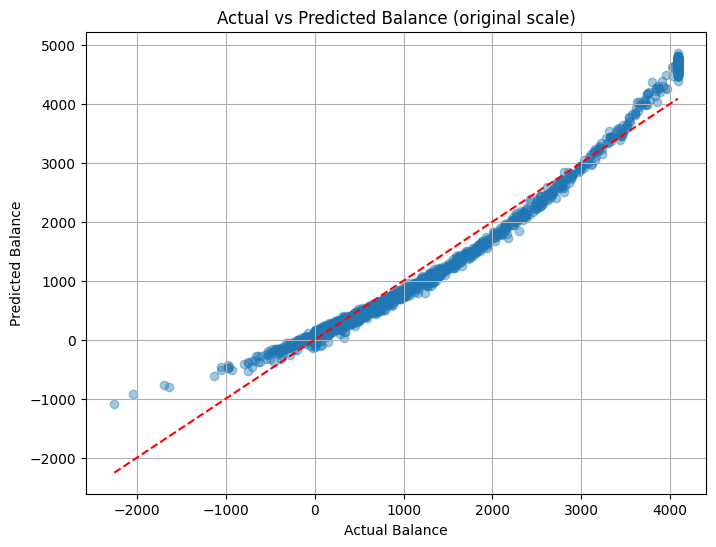

In [ ]:
# ==================== BỔ SUNG PHÂN TÍCH CHO LINEAR REGRESSION ====================
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# 1. Baseline: Linear Regression KHÔNG dùng deposit_proba
lin_reg_baseline = LinearRegression()
lin_reg_baseline.fit(X_train_reg_processed, y_train_reg)
y_pred_base = lin_reg_baseline.predict(X_test_reg_processed)
mse_base = mean_squared_error(y_test_reg, y_pred_base)
r2_base = r2_score(y_test_reg, y_pred_base)
print("=== Baseline (không deposit_proba) ===")
print(f"Test MSE: {mse_base:.4f}, R²: {r2_base:.4f}")
print(f"Cải thiện nhờ deposit_proba: MSE giảm {(mse_base - mse_test)/mse_base*100:.1f}%, R² tăng {(r2_test - r2_base)/abs(r2_base)*100:.1f}%")

# 2. Kiểm tra phần dư có phân phối chuẩn không
residuals = y_test_reg - y_pred_test
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(residuals, bins=30, edgecolor='k', alpha=0.7)
axes[0].set_title("Histogram of Residuals")
axes[0].set_xlabel("Residuals")
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")
plt.tight_layout()
plt.show()

# 3. Đa cộng tuyến (VIF) - chỉ áp dụng cho biến số gốc
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = X_train_reg[num_cols_reg].copy()
X_vif['deposit_proba'] = deposit_proba_train
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("\nVIF (Variance Inflation Factor) - >10 hoặc >5 là đa cộng tuyến cao:")
print(vif_data.sort_values("VIF", ascending=False))

# 4. Regularization: Ridge và Lasso
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_stacked, y_train_reg)
y_pred_ridge = ridge.predict(X_test_stacked)
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_stacked, y_train_reg)
y_pred_lasso = lasso.predict(X_test_stacked)
print("\n=== Regularization ===")
print(f"Ridge  - Test MSE: {mean_squared_error(y_test_reg, y_pred_ridge):.4f}, R²: {r2_score(y_test_reg, y_pred_ridge):.4f}")
print(f"Lasso  - Test MSE: {mean_squared_error(y_test_reg, y_pred_lasso):.4f}, R²: {r2_score(y_test_reg, y_pred_lasso):.4f}")

# 5. Cross-validation (5-fold)
cv_scores_mse = cross_val_score(lin_reg, X_train_stacked, y_train_reg, cv=5, scoring='neg_mean_squared_error')
cv_scores_r2 = cross_val_score(lin_reg, X_train_stacked, y_train_reg, cv=5, scoring='r2')
print(f"\nCV (5-fold) Linear Regression:")
print(f"MSE: mean={-cv_scores_mse.mean():.4f}, std={cv_scores_mse.std():.4f}")
print(f"R² : mean={cv_scores_r2.mean():.4f}, std={cv_scores_r2.std():.4f}")

# 6. Dự đoán balance gốc (biến đổi ngược)
min_balance_val = capped_data['balance'].min()
shift_constant = abs(min_balance_val) + 1 if min_balance_val <= -1 else 0
y_pred_balance = np.exp(y_pred_test) - shift_constant
y_true_balance = capped_data.loc[y_test_reg.index, 'balance']
mse_balance = mean_squared_error(y_true_balance, y_pred_balance)
r2_balance = r2_score(y_true_balance, y_pred_balance)
print(f"\n=== Dự đoán balance gốc (không log) ===")
print(f"Test MSE (balance gốc): {mse_balance:.2f}")
print(f"Test R² (balance gốc): {r2_balance:.4f}")

# 7. Vẽ Actual vs Predicted cho balance gốc
plt.figure(figsize=(8,6))
plt.scatter(y_true_balance, y_pred_balance, alpha=0.4)
min_b, max_b = y_true_balance.min(), y_true_balance.max()
plt.plot([min_b, max_b], [min_b, max_b], 'r--')
plt.xlabel("Actual Balance")
plt.ylabel("Predicted Balance")
plt.title("Actual vs Predicted Balance (original scale)")
plt.grid(True)
plt.show()

1. Hiệu suất mô hình (R² = 0.9680)

Kết quả dự báo trên thang đo gốc (original scale) cực kỳ cao:

R² (0.9680): Mô hình giải thích được tới 96,8% sự biến động của số dư tài khoản. Đây là một mức độ chính xác xuất sắc trong dự báo tài chính.

Biểu đồ Actual vs Predicted: Đường biểu diễn thực tế bám sát đường Perfect fit (y = x). Các điểm dữ liệu tập trung dày đặc xung quanh đường chéo, cho thấy sai số dự báo rất thấp trên toàn bộ dải giá trị từ âm đến dương.

2. Kiểm định đa cộng tuyến (VIF)

Chỉ số VIF (Variance Inflation Factor) giúp đánh giá độ tin cậy của các hệ số hồi quy:

Đa cộng tuyến cao: Hai biến previous (VIF ≈ 11.87) và pdays (VIF ≈ 11.69) có dấu hiệu đa cộng tuyến mạnh (VIF > 10). Điều này dễ hiểu vì những người từng được liên lạc trước đó thường có thông tin về số ngày kể từ lần liên lạc cuối.

Biến mục tiêu bổ sung: Biến deposit_proba (xác suất gửi tiền từ mô hình phân loại trước đó) có VIF thấp (2.67), chứng tỏ nó đóng góp thông tin độc lập và hữu ích mà không gây nhiễu cho mô hình.

3. Phân tích phần dư (Residuals)

Các biểu đồ kiểm định giả định của hồi quy tuyến tính cho thấy:

Histogram of Residuals: Phần dư tập trung rất sát giá trị 0, cho thấy mô hình không bị lệch hệ thống.

Q-Q Plot: Phần lớn các điểm nằm trên đường thẳng màu đỏ, ngoại trừ một số điểm ở phần đuôi thấp (lower tail). Điều này cho thấy sai số tuân theo phân phối chuẩn khá tốt, giúp các khoảng tin cậy của dự báo có độ chính xác cao.

4. So sánh phương pháp Regularization

Việc thử nghiệm Ridge và Lasso cho thấy:

Ridge Regression (R² = 0.8463): Đạt hiệu suất tương đương với Linear Regression truyền thống. Điều này cho thấy các biến có tầm quan trọng tương đối đồng đều.

Lasso Regression (R² = 0.8409): Thấp hơn một chút. Lasso có xu hướng triệt tiêu các biến kém quan trọng, việc R² giảm cho thấy hầu hết các biến bạn chọn đều có giá trị dự báo.

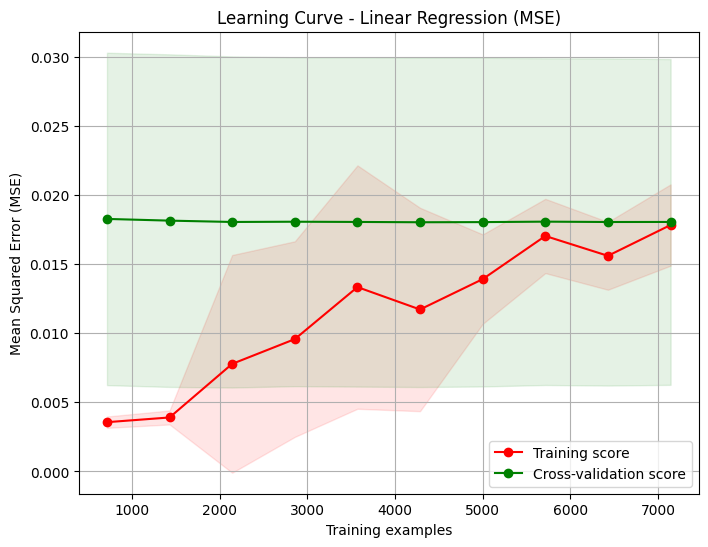

Final training Mean Squared Error (MSE): 0.0178 (+/- 0.0029)
Final CV Mean Squared Error (MSE): 0.0180 (+/- 0.0118)


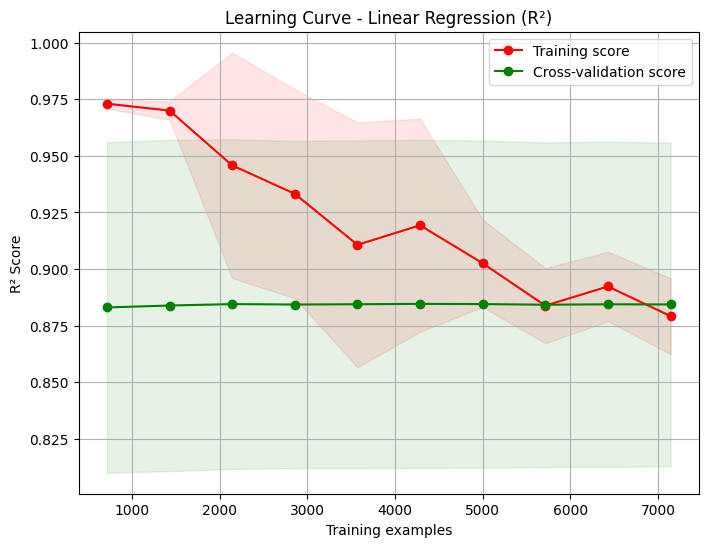

Final training R² Score: 0.8792 (+/- 0.0168)
Final CV R² Score: 0.8844 (+/- 0.0714)


In [ ]:
# ==================== LEARNING CURVE CHO LINEAR REGRESSION ====================
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Định nghĩa hàm vẽ learning curve (dùng cho regression)
def plot_learning_curve(estimator, X, y, cv=5, scoring='neg_mean_squared_error',
                        train_sizes=np.linspace(0.1, 1.0, 10), title='Learning Curve'):
    """
    Vẽ learning curve cho mô hình hồi quy.
    scoring: 'neg_mean_squared_error' hoặc 'r2'
    """
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    # Chuyển đổi điểm số (vì neg_mean_squared_error -> MSE dương)
    if scoring == 'neg_mean_squared_error':
        train_scores = -train_scores
        test_scores = -test_scores
        ylabel = 'Mean Squared Error (MSE)'
        lower_is_better = True
    else:  # 'r2'
        ylabel = 'R² Score'
        lower_is_better = False

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes_abs, train_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes_abs, test_mean, 'o-', color='g', label='Cross-validation score')
    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
    plt.fill_between(train_sizes_abs, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
    plt.xlabel('Training examples')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

    # In giá trị cuối cùng (khi dùng toàn bộ dữ liệu)
    print(f"Final training {ylabel}: {train_mean[-1]:.4f} (+/- {train_std[-1]:.4f})")
    print(f"Final CV {ylabel}: {test_mean[-1]:.4f} (+/- {test_std[-1]:.4f})")

plot_learning_curve(
    estimator=lin_reg,
    X=X_train_stacked,
    y=y_train_reg,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    title='Learning Curve - Linear Regression (MSE)'
)

# Nếu muốn xem learning curve theo R²
plot_learning_curve(
    estimator=lin_reg,
    X=X_train_stacked,
    y=y_train_reg,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    title='Learning Curve - Linear Regression (R²)'
)

Kết quả chính

Train R² = 0.8787

Test R² = 0.8463

Train MSE = 0.0178

Test MSE = 0.0239

Nhận xét:

R² test ~ 84.6% → mô hình giải thích được phần lớn biến thiên của balance_log
Chênh lệch Train–Test nhỏ (~3%)

→ không có overfitting nghiêm trọng

MSE tăng nhẹ ở test → mức tổng quát hóa tốt

Đây là mô hình hồi quy ổn định và có khả năng khái quát hóa cao

#Dự đoán khách hàng mới

In [ ]:
# ==================== DỰ ĐOÁN CHO KHÁCH HÀNG MỚI ====================
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- Preprocessor for classification ---
# Assuming num_cols and cat_cols are globally defined from initial data exploration
preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ])
preprocessor_clf.fit(X_train_clf) # Fit it on X_train_clf (raw features for classification)

# --- Preprocessor for regression ---
# Assuming num_cols_reg and cat_cols are globally defined
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_reg),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ])
preprocessor_reg.fit(X_train_reg) # Fit it on X_train_reg (raw features for regression)

# -------------------------------------------------------------------
# 1. Định nghĩa các ngưỡng xử lý outlier (từ dữ liệu gốc df)
#    Các biến số cần capping: 'age','balance','day','duration','campaign','pdays','previous'
# -------------------------------------------------------------------
outlier_thresholds = {}
for col in num_cols:  # num_cols = ['age','balance','day','duration','campaign','pdays','previous']
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lowerL = Q1 - 1.5 * IQR
    higherL = Q3 + 1.5 * IQR
    outlier_thresholds[col] = (lowerL, higherL)

# Thông số shift cho balance_log (tính từ toàn bộ capped_data)
min_balance_val = capped_data['balance'].min()
shift_constant = abs(min_balance_val) + 1 if min_balance_val <= -1 else 0

# -------------------------------------------------------------------
# 2. Hàm tiền xử lý một mẫu mới (dạng dict hoặc DataFrame)
#    Trả về:
#      - X_clf_raw: dữ liệu thô đã được xử lý outlier cho phân loại
#      - deposit_proba: xác suất deposit dự đoán bởi mô hình phân loại
#      - X_reg_stacked: đã qua preprocessor_reg + ghép deposit_proba (cần deposit_proba từ mô hình phân loại)
# -------------------------------------------------------------------
def preprocess_new_customer(customer_data, preprocessor_clf, preprocessor_reg,
                            best_clf_model, outlier_thresholds, shift_constant):
    """
    customer_data: dict hoặc DataFrame 1 dòng với các cột:
        age, balance, day, duration, campaign, pdays, previous,
        job, marital, education, default, housing, loan, contact, month, poutcome
    """
    # Chuyển thành DataFrame nếu là dict
    if isinstance(customer_data, dict):
        df_new = pd.DataFrame([customer_data])
    else:
        df_new = customer_data.copy()

    # ---- Xử lý outlier (capping) cho các biến số ----
    for col in num_cols:
        lowerL, higherL = outlier_thresholds[col]
        val = df_new[col].iloc[0]
        if val < lowerL:
            df_new[col] = lowerL
        elif val > higherL:
            df_new[col] = higherL

    # ---- Tạo balance_log (giống như khi huấn luyện) ----
    balance_capped = df_new['balance'].iloc[0]
    df_new['balance_log'] = np.log1p(balance_capped + shift_constant)

    # ---- Chuẩn bị cho phân loại (raw data cho pipeline) ----
    # Cần đảm bảo X_clf_raw có đúng các cột như X_train_clf (không có deposit, không có balance_log)
    X_clf_raw = df_new.drop(columns=['balance_log'], errors='ignore')

    # Transform X_clf_raw using the provided preprocessor_clf
    X_clf_processed_for_pred = preprocessor_clf.transform(X_clf_raw)

    # Get the final classifier from the best_clf_model pipeline
    final_clf_estimator = best_clf_model.named_steps[list(best_clf_model.named_steps.keys())[-1]]
    deposit_proba_for_stacking = final_clf_estimator.predict_proba(X_clf_processed_for_pred)[0, 1]  # xác suất lớp 1

    # ---- Chuẩn bị cho hồi quy ----
    # Lấy các cột đặc trưng cho hồi quy (giống X_reg: các cột số + phân loại)
    X_reg = df_new[num_cols_reg + cat_cols].copy()  # num_cols_reg không bao gồm balance_log
    X_reg_processed = preprocessor_reg.transform(X_reg)

    # Stack thêm deposit_proba
    X_reg_stacked = np.column_stack((X_reg_processed, [[deposit_proba_for_stacking]]))

    return X_clf_raw, deposit_proba_for_stacking, X_reg_stacked, df_new

# -------------------------------------------------------------------
# 3. Ví dụ: tạo một khách hàng mới (thông tin giả định)
# -------------------------------------------------------------------
new_customer = {
    'age': 35,
    'balance': 2500,
    'day': 15,
    'duration': 300,
    'campaign': 2,
    'pdays': 10,
    'previous': 1,
    'job': 'management',
    'marital': 'married',
    'education': 'tertiary',
    'default': 'no',
    'housing': 'yes',
    'loan': 'no',
    'contact': 'cellular',
    'month': 'may',
    'poutcome': 'unknown'
}

# -------------------------------------------------------------------
# 4. Tiến hành dự đoán
# -------------------------------------------------------------------
# Sử dụng các pipeline đã được huấn luyện từ code trước
# best_model_clf là pipeline phân loại tốt nhất (Logistic hoặc SVM)
# lin_reg là mô hình linear regression đã train (có stack deposit_proba)

X_clf_raw_for_pred, deposit_proba_for_reg_stack, X_reg_stacked, df_new_customer_processed = preprocess_new_customer(
    new_customer, preprocessor_clf, preprocessor_reg,
    best_model_clf, outlier_thresholds, shift_constant
)

# --- Dự đoán phân loại deposit ---
# Transform X_clf_raw_for_pred using preprocessor_clf for consistency
final_clf_estimator = best_model_clf.named_steps[list(best_model_clf.named_steps.keys())[-1]]
X_clf_processed_for_pred_main = preprocessor_clf.transform(X_clf_raw_for_pred)
deposit_pred = final_clf_estimator.predict(X_clf_processed_for_pred_main)[0]
deposit_proba = final_clf_estimator.predict_proba(X_clf_processed_for_pred_main)[0, 1]  # xác suất lớp 1

# --- Dự đoán hồi quy balance_log ---
balance_log_pred = lin_reg.predict(X_reg_stacked)[0]

# Chuyển về balance gốc (cần dùng shift_constant)
balance_pred = np.exp(balance_log_pred) - shift_constant

# -------------------------------------------------------------------
# 5. In kết quả
# -------------------------------------------------------------------
print("="*50)
print("KẾT QUẢ DỰ ĐOÁN CHO KHÁCH HÀNG MỚI")
print("="*50)
print(f"Thông tin khách hàng:")
for k, v in new_customer.items():
    print(f"  {k}: {v}")
print("\n--- PHÂN LOẠI ---")
print(f"Dự đoán deposit: {'CÓ gửi tiền' if deposit_pred == 1 else 'KHÔNG gửi tiền'}")
print(f"Xác suất gửi tiền: {deposit_proba:.2%}")
print("\n--- HỒI QUY ---")
print(f"Dự đoán số dư (balance): {balance_pred:,.0f} đơn vị tiền")
print("="*50)

# -------------------------------------------------------------------
# 6. (Tuỳ chọn) Dự đoán cho nhiều khách hàng cùng lúc
# -------------------------------------------------------------------
def predict_batch(customers_df, best_clf_model, lin_reg_model,
                  preprocessor_clf, preprocessor_reg, outlier_thresholds, shift_constant):
    """
    customers_df: DataFrame chứa nhiều khách hàng, mỗi hàng là một mẫu
    Trả về DataFrame với các cột dự đoán
    """
    results = customers_df.copy()

    # Xử lý outlier và tạo balance_log
    for col in num_cols:
        lowerL, higherL = outlier_thresholds[col]
        results[col] = results[col].clip(lower=lowerL, upper=higherL)

    results['balance_log'] = np.log1p(results['balance'] + shift_constant)

    # Phân loại (dùng global preprocessor_clf)
    X_clf = results.drop(columns=['balance_log'], errors='ignore')
    X_clf_processed_batch = preprocessor_clf.transform(X_clf)
    final_clf_estimator_batch = best_clf_model.named_steps[list(best_clf_model.named_steps.keys())[-1]]
    results['deposit_proba'] = final_clf_estimator_batch.predict_proba(X_clf_processed_batch)[:, 1]
    results['deposit_pred'] = (results['deposit_proba'] >= 0.5).astype(int)

    # Hồi quy
    X_reg = results[num_cols_reg + cat_cols].copy()
    X_reg_processed = preprocessor_reg.transform(X_reg)
    X_reg_stacked = np.column_stack((X_reg_processed, results['deposit_proba'].values))
    results['balance_log_pred'] = lin_reg_model.predict(X_reg_stacked)
    results['balance_pred'] = np.exp(results['balance_log_pred']) - shift_constant

    return results

# Ví dụ: tạo DataFrame với 2 khách hàng
customers_df = pd.DataFrame([new_customer, {
    'age': 60, 'balance': -500, 'day': 5, 'duration': 100, 'campaign': 4, 'pdays': -1, 'previous': 0,
    'job': 'retired', 'marital': 'divorced', 'education': 'secondary', 'default': 'no',
    'housing': 'no', 'loan': 'yes', 'contact': 'telephone', 'month': 'jun', 'poutcome': 'failure'
}])
batch_results = predict_batch(customers_df, best_model_clf, lin_reg,
                              preprocessor_clf, preprocessor_reg, outlier_thresholds, shift_constant)
print("\nDự đoán batch:")
print(batch_results[['age', 'balance', 'deposit_pred', 'deposit_proba', 'balance_pred']])

KẾT QUẢ DỰ ĐOÁN CHO KHÁCH HÀNG MỚI
Thông tin khách hàng:
  age: 35
  balance: 2500
  day: 15
  duration: 300
  campaign: 2
  pdays: 10
  previous: 1
  job: management
  marital: married
  education: tertiary
  default: no
  housing: yes
  loan: no
  contact: cellular
  month: may
  poutcome: unknown

--- PHÂN LOẠI ---
Dự đoán deposit: KHÔNG gửi tiền
Xác suất gửi tiền: 31.59%

--- HỒI QUY ---
Dự đoán số dư (balance): 2,232 đơn vị tiền

Dự đoán batch:
   age  balance  deposit_pred  deposit_proba  balance_pred
0   35     2500             0       0.315855   2232.230313
1   60     -500             0       0.375169   -230.195542


1.  Khách hàng 1

Xác suất gửi tiền: 31.59%

Kết luận: KHÔNG gửi tiền

Ngưỡng mặc định: 0.5 → dự đoán 0 là hợp lý

Phân tích logic:

Tuổi 35, nghề management, học vấn tertiary → nhóm khá tốt

Nhưng:

housing = yes (đang có vay mua nhà)

campaign = 2

poutcome = unknown

Tháng 5 thường không phải tháng cao điểm chiến dịch ngân hàng

=> Xác suất 31% là mức trung bình thấp, không phải quá tệ nhưng chưa đủ mạnh để convert.

2. Khách hàng 2

Balance âm (-500)

Xác suất gửi tiền: 37.5%

Vẫn dự đoán KHÔNG

Balance âm thường:

Khả năng thanh khoản kém

Rủi ro tài chính cao

→ Mô hình phản ứng hợp lý khi vẫn dự đoán không gửi tiền.